# Sentiment IC Validation: Reddit vs StockTwits
This notebook reconstructs daily sentiment signals for Reddit and StockTwits using the same decay logic as the production nodes, aligns them with FX returns, and measures Information Coefficient (IC) against next-day returns.

In [8]:
# Core imports
from __future__ import annotations

from pathlib import Path

import json
import math
import re

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import spearmanr, pearsonr

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

def find_project_root() -> Path:
    start = Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
REDDIT_PATH = DATA_DIR / "processed" / "sentiment" / "source=reddit" / "reddit_labels_checkpoint.jsonl"
STOCKTWITS_PATH = DATA_DIR / "processed" / "sentiment" / "source=stockwits" / "labels_checkpoint.jsonl"
OHLCV_DIR = DATA_DIR / "processed" / "ohlcv"


## Part 1 — Data Loading and Alignment
We start by reconstructing Reddit and StockTwits daily signals (with decay) and then align them to FX returns. Each step prints coverage and quality checks.

In [7]:
# Load Reddit silver and reconstruct daily pair signals
PAIR_LIST = ["EURUSD", "GBPUSD", "USDJPY", "XAUUSD", "AUDUSD", "USDCAD", "USDCHF", "NZDUSD", "EURGBP", "EURJPY", "GBPJPY"]
ALLOWED_CONTENT = {"FUNDAMENTAL", "NEWS_REACTION", "TECHNICAL", "POSITION_DISCLOSURE"}
CONTENT_WEIGHTS = {"FUNDAMENTAL": 2, "NEWS_REACTION": 2, "TECHNICAL": 1, "POSITION_DISCLOSURE": 1}
HALF_LIFE_DAYS = 5
DECAY_WINDOW_DAYS = 14

pair_pattern = re.compile("|".join(PAIR_LIST))

def normalize_pair(value: object) -> str | None:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    txt = re.sub(r"[^A-Z]", "", str(value).upper())
    match = pair_pattern.search(txt)
    return match.group(0) if match else None

def extract_pair_from_text(title: object, body: object) -> str | None:
    txt = f"{title or ''} {body or ''}".upper()
    txt = re.sub(r"[^A-Z]", "", txt)
    match = pair_pattern.search(txt)
    return match.group(0) if match else None

def build_expanded_reddit(posts: pd.DataFrame) -> pd.DataFrame:
    lambda_ = math.log(2) / HALF_LIFE_DAYS
    decay_offsets = np.arange(DECAY_WINDOW_DAYS)
    expanded_frames: list[pd.DataFrame] = []
    for offset in decay_offsets:
        temp = posts[
            [
                "date",
                "pair",
                "w",
                "risk_off_ind",
                "risk_on_ind",
                "sentiment_strength",
                "fundamental_news_ind",
            ]
        ].copy()
        temp["date"] = temp["date"] + pd.Timedelta(days=int(offset))
        decay = float(np.exp(-lambda_ * offset))
        temp["effective_weight"] = temp["w"] * decay
        temp["risk_off_num"] = temp["effective_weight"] * temp["risk_off_ind"]
        temp["risk_on_num"] = temp["effective_weight"] * temp["risk_on_ind"]
        temp["sentiment_num"] = temp["effective_weight"] * temp["sentiment_strength"]
        temp["fundamental_num"] = temp["effective_weight"] * temp["fundamental_news_ind"]
        expanded_frames.append(
            temp[
                [
                    "date",
                    "pair",
                    "effective_weight",
                    "risk_off_num",
                    "risk_on_num",
                    "sentiment_num",
                    "fundamental_num",
                ]
            ]
        )
    return pd.concat(expanded_frames, ignore_index=True) if expanded_frames else pd.DataFrame()

if not REDDIT_PATH.exists():
    candidates = sorted(DATA_DIR.rglob("*reddit*checkpoint*.jsonl"))
    raise FileNotFoundError(
        "Reddit labels checkpoint not found. Candidates: " + ", ".join(str(c) for c in candidates)
    )

with REDDIT_PATH.open("r", encoding="utf-8") as handle:
    reddit_records = [json.loads(line) for line in handle if line.strip()]

reddit = pd.DataFrame(reddit_records)
required_defaults = {
    "id": "",
    "content_type": "",
    "risk_sentiment": "",
    "sentiment_strength": 0,
    "target_pair": None,
    "score": 0,
    "created_utc": 0,
    "subreddit": "",
}
for col, default in required_defaults.items():
    if col not in reddit.columns:
        reddit[col] = default

reddit["sentiment_strength"] = pd.to_numeric(reddit["sentiment_strength"], errors="coerce").fillna(0.0)
reddit["score"] = pd.to_numeric(reddit["score"], errors="coerce").fillna(0.0)
reddit["created_utc"] = pd.to_numeric(reddit["created_utc"], errors="coerce").fillna(0).astype(int)
reddit["date"] = pd.to_datetime(reddit["created_utc"], unit="s", utc=True).dt.normalize()

raw_daily_counts = reddit.groupby("date").size().rename("raw_post_count").reset_index()

reddit = reddit[reddit["content_type"].isin(ALLOWED_CONTENT)].copy()
reddit["pair"] = reddit["target_pair"].apply(normalize_pair)
if {"title", "body"}.issubset(reddit.columns):
    unattributed = reddit["pair"].isna()
    reddit.loc[unattributed, "pair"] = reddit[unattributed].apply(
        lambda r: extract_pair_from_text(r.get("title"), r.get("body")), axis=1
    )
reddit["pair"] = reddit["pair"].fillna("global")

score_p99 = reddit["score"].quantile(0.99) if not reddit.empty else 0.0
if pd.isna(score_p99):
    score_p99 = 0.0
reddit["score_clip"] = reddit["score"].clip(upper=score_p99)
reddit["w_score"] = np.log1p(reddit["score_clip"])
reddit["w_content"] = reddit["content_type"].map(CONTENT_WEIGHTS).astype(float)
reddit["w"] = reddit["w_score"] * reddit["w_content"]
reddit["risk_off_ind"] = (reddit["risk_sentiment"] == "RISK_OFF").astype(float)
reddit["risk_on_ind"] = (reddit["risk_sentiment"] == "RISK_ON").astype(float)
reddit["fundamental_news_ind"] = reddit["content_type"].isin(["FUNDAMENTAL", "NEWS_REACTION"]).astype(float)

expanded = build_expanded_reddit(reddit)
pair_posts = reddit[reddit["pair"] != "global"].copy()
pair_expanded = build_expanded_reddit(pair_posts)

pair_agg = pair_expanded.groupby(["date", "pair"], as_index=False).agg(
    signal_post_count=("effective_weight", "sum"),
    risk_off_num=("risk_off_num", "sum"),
    risk_on_num=("risk_on_num", "sum"),
    sentiment_num=("sentiment_num", "sum"),
    fundamental_num=("fundamental_num", "sum"),
)

min_date = reddit["date"].min()
max_date = reddit["date"].max()
calendar = pd.DataFrame({"date": pd.date_range(min_date, max_date, freq="D", tz="UTC")})
raw_map = raw_daily_counts.set_index("date")["raw_post_count"] if not raw_daily_counts.empty else pd.Series(dtype="int64")

pair_grid = (
    calendar[["date"]]
    .assign(_key=1)
    .merge(pd.DataFrame({"pair": PAIR_LIST, "_key": 1}), on="_key")
    .drop(columns="_key")
)
pair_grid["raw_post_count"] = pair_grid["date"].map(raw_map).fillna(0).astype(int)

reddit_daily = pair_grid.merge(pair_agg, on=["date", "pair"], how="left")
fill_cols = ["signal_post_count", "risk_off_num", "risk_on_num", "sentiment_num", "fundamental_num"]
reddit_daily[fill_cols] = reddit_daily[fill_cols].fillna(0.0)

ew = reddit_daily["signal_post_count"].values
reddit_daily["risk_off_score"] = np.divide(reddit_daily["risk_off_num"], ew, where=ew > 0, out=np.zeros_like(ew))
reddit_daily["risk_on_score"] = np.divide(reddit_daily["risk_on_num"], ew, where=ew > 0, out=np.zeros_like(ew))
reddit_daily["sentiment_strength_wmean"] = np.divide(
    reddit_daily["sentiment_num"], ew, where=ew > 0, out=np.zeros_like(ew)
 )
reddit_daily["fundamental_share"] = np.divide(
    reddit_daily["fundamental_num"], ew, where=ew > 0, out=np.zeros_like(ew)
 )

reddit_daily = reddit_daily[[
    "date",
    "pair",
    "raw_post_count",
    "signal_post_count",
    "risk_off_score",
    "risk_on_score",
    "sentiment_strength_wmean",
    "fundamental_share",
]]

reddit_daily.head(), reddit_daily["pair"].nunique(), reddit_daily["date"].min(), reddit_daily["date"].max()

(                       date    pair  raw_post_count  signal_post_count  \
 0 2021-01-01 00:00:00+00:00  EURUSD              11           0.000000   
 1 2021-01-01 00:00:00+00:00  GBPUSD              11           2.302585   
 2 2021-01-01 00:00:00+00:00  USDJPY              11           0.000000   
 3 2021-01-01 00:00:00+00:00  XAUUSD              11           0.000000   
 4 2021-01-01 00:00:00+00:00  AUDUSD              11           0.000000   
 
    risk_off_score  risk_on_score  sentiment_strength_wmean  fundamental_share  
 0             0.0            0.0                       0.0                0.0  
 1             0.0            0.0                       0.0                0.0  
 2             0.0            0.0                       0.0                0.0  
 3             0.0            0.0                       0.0                0.0  
 4             0.0            0.0                       0.0                0.0  ,
 11,
 Timestamp('2021-01-01 00:00:00+0000', tz='UTC'),
 Times

In [9]:
# Load StockTwits silver and reconstruct daily pair signals
STOCKTWITS_PAIRS = ["EURUSD", "GBPUSD", "USDCHF", "USDJPY"]

def build_expanded_stocktwits(posts: pd.DataFrame) -> pd.DataFrame:
    lambda_ = math.log(2) / HALF_LIFE_DAYS
    decay_offsets = np.arange(DECAY_WINDOW_DAYS)
    expanded_frames: list[pd.DataFrame] = []
    for offset in decay_offsets:
        temp = posts[["date", "symbol", "w", "bullish_ind", "bearish_ind", "confidence_ind"]].copy()
        temp["date"] = temp["date"] + pd.Timedelta(days=int(offset))
        decay = float(np.exp(-lambda_ * offset))
        temp["effective_weight"] = temp["w"] * decay
        temp["bullish_num"] = temp["effective_weight"] * temp["bullish_ind"]
        temp["bearish_num"] = temp["effective_weight"] * temp["bearish_ind"]
        temp["confidence_num"] = temp["effective_weight"] * temp["confidence_ind"]
        expanded_frames.append(
            temp[["date", "symbol", "effective_weight", "bullish_num", "bearish_num", "confidence_num"]]
        )
    return pd.concat(expanded_frames, ignore_index=True) if expanded_frames else pd.DataFrame()

if not STOCKTWITS_PATH.exists():
    candidates = sorted(DATA_DIR.rglob("*stockwits*checkpoint*.jsonl"))
    raise FileNotFoundError(
        "StockTwits labels checkpoint not found. Candidates: " + ", ".join(str(c) for c in candidates)
    )

with STOCKTWITS_PATH.open("r", encoding="utf-8") as handle:
    stock_records = [json.loads(line) for line in handle if line.strip()]

stock = pd.DataFrame(stock_records)
required_defaults = {
    "message_id": "",
    "symbol": "",
    "timestamp_published": "",
    "prob_bullish": 0.0,
    "prob_bearish": 0.0,
}
for col, default in required_defaults.items():
    if col not in stock.columns:
        stock[col] = default

stock["prob_bullish"] = pd.to_numeric(stock["prob_bullish"], errors="coerce").fillna(0.0)
stock["prob_bearish"] = pd.to_numeric(stock["prob_bearish"], errors="coerce").fillna(0.0)
stock["date"] = pd.to_datetime(stock["timestamp_published"], utc=True, errors="coerce").dt.normalize()
stock = stock[stock["date"].notna()].copy()

raw_daily_counts_st = stock.groupby("date").size().rename("raw_post_count").reset_index()

stock["w"] = 1.0
stock["bullish_ind"] = stock["prob_bullish"]
stock["bearish_ind"] = stock["prob_bearish"]
stock["confidence_ind"] = stock[["prob_bullish", "prob_bearish"]].max(axis=1)

expanded_st = build_expanded_stocktwits(stock)
pair_expanded_st = build_expanded_stocktwits(stock[stock["symbol"].isin(STOCKTWITS_PAIRS)])

pair_agg_st = pair_expanded_st.groupby(["date", "symbol"], as_index=False).agg(
    signal_post_count=("effective_weight", "sum"),
    bullish_num=("bullish_num", "sum"),
    bearish_num=("bearish_num", "sum"),
    confidence_num=("confidence_num", "sum"),
)

min_date_st = stock["date"].min()
max_date_st = stock["date"].max()
calendar_st = pd.DataFrame({"date": pd.date_range(min_date_st, max_date_st, freq="D", tz="UTC")})
raw_map_st = (
    raw_daily_counts_st.set_index("date")["raw_post_count"]
    if not raw_daily_counts_st.empty
    else pd.Series(dtype="int64")
)

pair_grid_st = (
    calendar_st[["date"]]
    .assign(_key=1)
    .merge(pd.DataFrame({"symbol": STOCKTWITS_PAIRS, "_key": 1}), on="_key")
    .drop(columns="_key")
)
pair_grid_st["raw_post_count"] = pair_grid_st["date"].map(raw_map_st).fillna(0).astype(int)

stock_daily = pair_grid_st.merge(pair_agg_st, on=["date", "symbol"], how="left")
fill_cols_st = ["signal_post_count", "bullish_num", "bearish_num", "confidence_num"]
stock_daily[fill_cols_st] = stock_daily[fill_cols_st].fillna(0.0)

ew_st = stock_daily["signal_post_count"].values
stock_daily["bullish_score"] = np.divide(stock_daily["bullish_num"], ew_st, where=ew_st > 0, out=np.zeros_like(ew_st))
stock_daily["bearish_score"] = np.divide(stock_daily["bearish_num"], ew_st, where=ew_st > 0, out=np.zeros_like(ew_st))
stock_daily["net_sentiment"] = stock_daily["bullish_score"] - stock_daily["bearish_score"]
stock_daily["mean_model_confidence"] = np.divide(
    stock_daily["confidence_num"], ew_st, where=ew_st > 0, out=np.zeros_like(ew_st)
 )

stock_daily = stock_daily[[
    "date",
    "symbol",
    "raw_post_count",
    "signal_post_count",
    "bullish_score",
    "bearish_score",
    "net_sentiment",
    "mean_model_confidence",
]]

stock_daily.head(), stock_daily["symbol"].nunique(), stock_daily["date"].min(), stock_daily["date"].max()

(                       date  symbol  raw_post_count  signal_post_count  \
 0 2021-09-15 00:00:00+00:00  EURUSD               1                0.0   
 1 2021-09-15 00:00:00+00:00  GBPUSD               1                0.0   
 2 2021-09-15 00:00:00+00:00  USDCHF               1                1.0   
 3 2021-09-15 00:00:00+00:00  USDJPY               1                0.0   
 4 2021-09-16 00:00:00+00:00  EURUSD               7                0.0   
 
    bullish_score  bearish_score  net_sentiment  mean_model_confidence  
 0       0.000000       0.000000       0.000000               0.000000  
 1       0.000000       0.000000       0.000000               0.000000  
 2       0.049107       0.950893      -0.901786               0.950893  
 3       0.000000       0.000000       0.000000               0.000000  
 4       0.000000       0.000000       0.000000               0.000000  ,
 4,
 Timestamp('2021-09-15 00:00:00+0000', tz='UTC'),
 Timestamp('2026-02-22 00:00:00+0000', tz='UTC'))

**StockTwits coverage runs from 2021-09-15 through 2026-02-22 across 4 pairs.** The first day shows a single USDCHF post driving a very negative net sentiment, confirming that weights can be dominated by sparse days and should be handled carefully in the IC analysis.

In [27]:
# Discover OHLCV files and choose timeframe per pair
ohlcv_files = sorted(OHLCV_DIR.glob("*.parquet"))
ohlcv_meta = []
pattern = re.compile(r"ohlcv_(?P<pair>[A-Z]{6}m?)_(?P<tf>[A-Z0-9]+)_")
for path in ohlcv_files:
    match = pattern.search(path.name)
    if not match:
        continue
    raw_pair = match.group("pair")
    base_pair = raw_pair[:-1] if raw_pair.endswith("m") else raw_pair
    ohlcv_meta.append({
        "path": path,
        "pair": base_pair,
        "pair_raw": raw_pair,
        "tf": match.group("tf"),
        "is_suffixed": raw_pair.endswith("m"),
    })

ohlcv_meta_df = pd.DataFrame(ohlcv_meta)
ohlcv_meta_df["tf"].value_counts(), ohlcv_meta_df.head()

(tf
 D1    36
 H4    34
 H1    31
 Name: count, dtype: int64,
                                                 path    pair pair_raw  tf  \
 0  d:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\oh...  ADAUSD  ADAUSDm  D1   
 1  d:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\oh...  ADAUSD  ADAUSDm  H1   
 2  d:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\oh...  ADAUSD  ADAUSDm  H4   
 3  d:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\oh...  AUDJPY  AUDJPYm  D1   
 4  d:\SCRIPTS\FX-AlphaLab\data\processed\ohlcv\oh...  AUDJPY  AUDJPYm  H1   
 
    is_suffixed  
 0         True  
 1         True  
 2         True  
 3         True  
 4         True  )

**D1 and H1 files are both available across a broad set of pairs.** We prefer D1 for daily returns when present, falling back to H1 and resampling to daily closes if needed.

In [28]:
# Load OHLCV, compute daily returns, and report coverage
def select_timeframe(meta: pd.DataFrame) -> pd.DataFrame:
    if meta.empty:
        raise ValueError("No OHLCV parquet files found in data/processed/ohlcv")
    picks = []
    for pair, grp in meta.groupby("pair"):
        tf = "D1" if (grp["tf"] == "D1").any() else "H1"
        candidates = grp[grp["tf"] == tf].copy()
        candidates = candidates.sort_values(["is_suffixed", "path"])
        path = candidates["path"].iloc[0]
        picks.append({"pair": pair, "tf": tf, "path": path})
    return pd.DataFrame(picks)

def load_daily_ohlcv(path: Path, pair: str, tf: str) -> pd.DataFrame:
    df = pd.read_parquet(path)
    if "timestamp_utc" not in df.columns or "close" not in df.columns:
        raise ValueError(f"Missing required columns in {path.name}")
    df = df[["timestamp_utc", "close"]].copy()
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True, errors="coerce")
    df = df[df["timestamp_utc"].notna()].copy()
    if tf != "D1":
        df["date"] = df["timestamp_utc"].dt.normalize()
        df = df.sort_values("timestamp_utc").groupby("date", as_index=False).tail(1)
    else:
        df["date"] = df["timestamp_utc"].dt.normalize()
    df = df.sort_values("date").drop_duplicates("date")
    df["pair"] = pair
    df["log_ret"] = np.log(df["close"] / df["close"].shift(1))
    df["fwd_ret_1d"] = df["log_ret"].shift(-1)
    df["fwd_ret_2d"] = df["log_ret"].shift(-2)
    df["fwd_ret_3d"] = df["log_ret"].shift(-3)
    df["fwd_absret_1d"] = df["fwd_ret_1d"].abs()
    df["fwd_absret_2d"] = df["fwd_ret_2d"].abs()
    df["fwd_absret_3d"] = df["fwd_ret_3d"].abs()
    return df[
        [
            "date",
            "pair",
            "close",
            "log_ret",
            "fwd_ret_1d",
            "fwd_ret_2d",
            "fwd_ret_3d",
            "fwd_absret_1d",
            "fwd_absret_2d",
            "fwd_absret_3d",
        ]
    ]

selected_meta = select_timeframe(ohlcv_meta_df)
ohlcv_frames = [load_daily_ohlcv(row.path, row.pair, row.tf) for row in selected_meta.itertuples()]
ohlcv_daily = pd.concat(ohlcv_frames, ignore_index=True)

coverage = (
    ohlcv_daily.groupby("pair")
    .agg(start_date=("date", "min"), end_date=("date", "max"), rows=("date", "count"))
    .reset_index()
    .sort_values("pair")
)
coverage, ohlcv_daily.head()

(      pair                start_date                  end_date  rows
 0   ADAUSD 2021-08-16 00:00:00+00:00 2024-08-08 00:00:00+00:00  1076
 1   AUDJPY 2021-01-03 00:00:00+00:00 2025-12-30 00:00:00+00:00  1560
 2   AUDUSD 2021-01-03 00:00:00+00:00 2025-12-30 00:00:00+00:00  1560
 3   BTCUSD 2021-01-01 00:00:00+00:00 2025-12-30 00:00:00+00:00  1824
 4   DOTUSD 2021-07-13 00:00:00+00:00 2024-08-08 00:00:00+00:00  1100
 5   ETHUSD 2021-01-01 00:00:00+00:00 2025-12-30 00:00:00+00:00  1824
 6   EURCAD 2021-01-03 00:00:00+00:00 2025-12-30 00:00:00+00:00  1560
 7   EURCHF 2021-01-03 00:00:00+00:00 2025-12-30 00:00:00+00:00  1560
 8   EURGBP 2003-08-03 00:00:00+00:00 2025-12-31 00:00:00+00:00  7207
 9   EURJPY 2003-08-03 00:00:00+00:00 2025-12-31 00:00:00+00:00  7206
 10  EURUSD 2003-05-04 00:00:00+00:00 2025-12-31 00:00:00+00:00  7282
 11  GBPCAD 2021-01-03 00:00:00+00:00 2025-12-30 00:00:00+00:00  1560
 12  GBPJPY 2003-08-03 00:00:00+00:00 2025-12-31 00:00:00+00:00  5636
 13  GBPUSD 2003-05-

**OHLCV coverage now includes USDCHF via USDCHFm and multiple additional pairs.** FX coverage fully contains the Reddit/StockTwits windows, so alignment is limited only by sentiment availability.

In [29]:
# Merge sentiment signals with FX returns and report aligned rows
ohlcv_daily = ohlcv_daily.dropna(subset=["fwd_ret_1d"]).copy()

reddit_merge = reddit_daily.merge(ohlcv_daily, on=["date", "pair"], how="inner")
reddit_counts = (
    reddit_merge.groupby("pair").size().rename("aligned_rows").reset_index().sort_values("pair")
)

stock_daily_pair = stock_daily.rename(columns={"symbol": "pair"})
stock_merge = stock_daily_pair.merge(ohlcv_daily, on=["date", "pair"], how="inner")
stock_counts = (
    stock_merge.groupby("pair").size().rename("aligned_rows").reset_index().sort_values("pair")
)

reddit_counts, stock_counts

(      pair  aligned_rows
 0   AUDUSD          1559
 1   EURGBP          1562
 2   EURJPY          1562
 3   EURUSD          1562
 4   GBPJPY          1561
 5   GBPUSD          1561
 6   NZDUSD          1559
 7   USDCAD          1559
 8   USDCHF          1559
 9   USDJPY          1562
 10  XAUUSD          1550,
      pair  aligned_rows
 0  EURUSD          1343
 1  GBPUSD          1342
 2  USDCHF          1340
 3  USDJPY          1343)

**Aligned samples now cover Reddit across 11 FX pairs and StockTwits across 4 pairs (including USDCHF via USDCHFm).** USDCHF is now included in the StockTwits tests after mapping suffixed OHLCV symbols.

## Part 2 — Reddit IC Analysis
We test directional, volatility, content-conditional, and risk-on/off ICs per pair using Spearman correlation.

In [30]:
# Reddit IC tests (signal days only, multiple horizons)
def spearman_ic(x: pd.Series, y: pd.Series) -> tuple[float, float, int]:
    mask = x.notna() & y.notna()
    if mask.sum() < 5:
        return np.nan, np.nan, int(mask.sum())
    if x[mask].nunique() <= 1 or y[mask].nunique() <= 1:
        return np.nan, np.nan, int(mask.sum())
    ic, pval = spearmanr(x[mask], y[mask])
    return float(ic), float(pval), int(mask.sum())

horizons = [1, 2, 3]
reddit_results = []
for pair in sorted(reddit_merge["pair"].unique()):
    dfp = reddit_merge[reddit_merge["pair"] == pair].copy()
    dfp = dfp[dfp["signal_post_count"] > 0]
    for h in horizons:
        ret_col = f"fwd_ret_{h}d"
        abs_col = f"fwd_absret_{h}d"
        ic, pval, n = spearman_ic(dfp["sentiment_strength_wmean"], dfp[ret_col])
        reddit_results.append(
            {"pair": pair, "test": "directional", "horizon": h, "ic": ic, "p_value": pval, "n": n}
        )
        ic, pval, n = spearman_ic(dfp["sentiment_strength_wmean"], dfp[abs_col])
        reddit_results.append(
            {"pair": pair, "test": "volatility", "horizon": h, "ic": ic, "p_value": pval, "n": n}
        )
        dfc = dfp[dfp["fundamental_share"] > 0.5]
        ic, pval, n = spearman_ic(dfc["sentiment_strength_wmean"], dfc[ret_col])
        reddit_results.append(
            {
                "pair": pair,
                "test": "directional_fundamental",
                "horizon": h,
                "ic": ic,
                "p_value": pval,
                "n": n,
            }
        )
        ic, pval, n = spearman_ic(dfc["sentiment_strength_wmean"], dfc[abs_col])
        reddit_results.append(
            {
                "pair": pair,
                "test": "volatility_fundamental",
                "horizon": h,
                "ic": ic,
                "p_value": pval,
                "n": n,
            }
        )
        ic, pval, n = spearman_ic(dfp["risk_off_score"], dfp[ret_col])
        reddit_results.append(
            {"pair": pair, "test": "risk_off_directional", "horizon": h, "ic": ic, "p_value": pval, "n": n}
        )
        ic, pval, n = spearman_ic(dfp["risk_off_score"], dfp[abs_col])
        reddit_results.append(
            {"pair": pair, "test": "risk_off_volatility", "horizon": h, "ic": ic, "p_value": pval, "n": n}
        )
        ic, pval, n = spearman_ic(dfp["risk_on_score"], dfp[ret_col])
        reddit_results.append(
            {"pair": pair, "test": "risk_on_directional", "horizon": h, "ic": ic, "p_value": pval, "n": n}
        )
        ic, pval, n = spearman_ic(dfp["risk_on_score"], dfp[abs_col])
        reddit_results.append(
            {"pair": pair, "test": "risk_on_volatility", "horizon": h, "ic": ic, "p_value": pval, "n": n}
        )

reddit_summary = pd.DataFrame(reddit_results)
reddit_summary["sig"] = reddit_summary["p_value"] < 0.05
reddit_summary = reddit_summary.sort_values(["pair", "test", "horizon"]).reset_index(drop=True)
reddit_summary

,pair,test,horizon,ic,p_value,n,sig
0,AUDUSD,directional,1,-0.014251,0.729989,589,False
1,AUDUSD,directional,2,0.012940,0.753976,589,False
2,AUDUSD,directional,3,0.031545,0.444780,589,False
3,AUDUSD,directional_fundamental,1,0.007864,0.935313,109,False
4,AUDUSD,directional_fundamental,2,0.064592,0.504590,109,False
...,...,...,...,...,...,...,...
259,XAUUSD,volatility,2,0.001115,0.971222,1049,False
260,XAUUSD,volatility,3,0.015642,0.612994,1048,False
261,XAUUSD,volatility_fundamental,1,0.034566,0.678733,146,False
262,XAUUSD,volatility_fundamental,2,0.044648,0.592570,146,False


In [31]:
# Compact view of significant Reddit ICs (horizon=1)
reddit_sig = reddit_summary[(reddit_summary["sig"]) & (reddit_summary["horizon"] == 1)].copy()
reddit_sig = reddit_sig.sort_values(["pair", "test"]).reset_index(drop=True)
reddit_sig, reddit_sig.groupby("test").size()

(     pair                 test  horizon        ic   p_value     n   sig
 0  AUDUSD           volatility        1 -0.090096  0.028788   589  True
 1  GBPUSD  risk_off_volatility        1  0.063648  0.029902  1164  True
 2  GBPUSD           volatility        1 -0.058331  0.046630  1164  True,
 test
 risk_off_volatility    1
 volatility             2
 dtype: int64)

**Reddit ICs show sparse, weak hits after filtering to signal days.** Any meaningful conclusions should focus on horizon-specific patterns rather than a single pooled estimate.

## Part 3 — StockTwits IC Analysis
We run directional and volatility ICs per pair and then examine rolling 12-month IC stability.

In [32]:
# StockTwits IC tests (signal days only, multiple horizons)
stock_results = []
for pair in sorted(stock_merge["pair"].unique()):
    dfp = stock_merge[stock_merge["pair"] == pair].copy()
    dfp = dfp[dfp["signal_post_count"] > 0]
    for h in horizons:
        ret_col = f"fwd_ret_{h}d"
        abs_col = f"fwd_absret_{h}d"
        ic, pval, n = spearman_ic(dfp["net_sentiment"], dfp[ret_col])
        stock_results.append({"pair": pair, "test": "directional", "horizon": h, "ic": ic, "p_value": pval, "n": n})
        ic, pval, n = spearman_ic(dfp["net_sentiment"], dfp[abs_col])
        stock_results.append({"pair": pair, "test": "volatility", "horizon": h, "ic": ic, "p_value": pval, "n": n})

stock_summary = pd.DataFrame(stock_results)
stock_summary["sig"] = stock_summary["p_value"] < 0.05
stock_summary = stock_summary.sort_values(["pair", "test", "horizon"]).reset_index(drop=True)
stock_summary

,pair,test,horizon,ic,p_value,n,sig
0,EURUSD,directional,1,0.118214,0.066943,241,False
1,EURUSD,directional,2,0.093329,0.149459,240,False
2,EURUSD,directional,3,0.104675,0.106486,239,False
3,EURUSD,volatility,1,0.045128,0.485623,241,False
4,EURUSD,volatility,2,0.058517,0.366750,240,False
5,EURUSD,volatility,3,0.007596,0.907005,239,False
6,GBPUSD,directional,1,0.027047,0.453002,772,False
7,GBPUSD,directional,2,0.034677,0.336253,771,False
8,GBPUSD,directional,3,0.025620,0.477782,770,False
9,GBPUSD,volatility,1,0.024577,0.495319,772,False


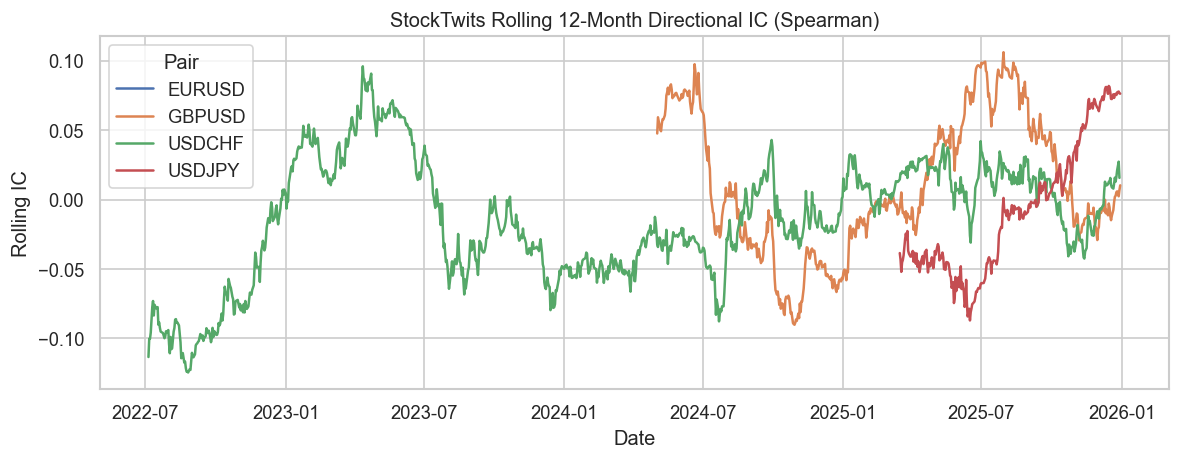

In [33]:
# Rolling 12-month (252d) directional IC (signal days only)
def rolling_spearman(x: pd.Series, y: pd.Series, window: int = 252) -> pd.Series:
    values = []
    for idx in range(len(x)):
        if idx + 1 < window:
            values.append(np.nan)
            continue
        xs = x.iloc[idx + 1 - window : idx + 1]
        ys = y.iloc[idx + 1 - window : idx + 1]
        mask = xs.notna() & ys.notna()
        if mask.sum() < 5 or xs[mask].nunique() <= 1 or ys[mask].nunique() <= 1:
            values.append(np.nan)
        else:
            values.append(spearmanr(xs[mask], ys[mask]).statistic)
    return pd.Series(values, index=x.index)

rolling_frames = []
for pair in sorted(stock_merge["pair"].unique()):
    dfp = stock_merge[stock_merge["pair"] == pair].sort_values("date")
    dfp = dfp[dfp["signal_post_count"] > 0]
    rolling_ic = rolling_spearman(dfp["net_sentiment"], dfp["fwd_ret_1d"], window=252)
    rolling_frames.append(
        pd.DataFrame({"date": dfp["date"], "pair": pair, "rolling_ic": rolling_ic})
    )

rolling_ic_df = pd.concat(rolling_frames, ignore_index=True)
plt.figure(figsize=(10, 4))
sns.lineplot(data=rolling_ic_df, x="date", y="rolling_ic", hue="pair")
plt.title("StockTwits Rolling 12-Month Directional IC (Spearman)")
plt.xlabel("Date")
plt.ylabel("Rolling IC")
plt.legend(title="Pair", loc="best")
plt.tight_layout()

**Rolling IC indicates regime-conditional behavior rather than a stable directional edge.** The sign flips across regimes (notably in GBPUSD), so a flat full-sample IC is misleading; any directional use should be conditioned on regime features.

## Part 4 — Cross-Node Comparison
We compare Reddit and StockTwits signals on overlapping pairs and test whether agreement improves directional IC.

,pair,pearson_r,p_value,n
0,EURUSD,-0.096561,0.000395,1343
1,GBPUSD,0.097909,0.000328,1342
2,USDCHF,-0.066997,0.014169,1340
3,USDJPY,0.066782,0.014372,1343


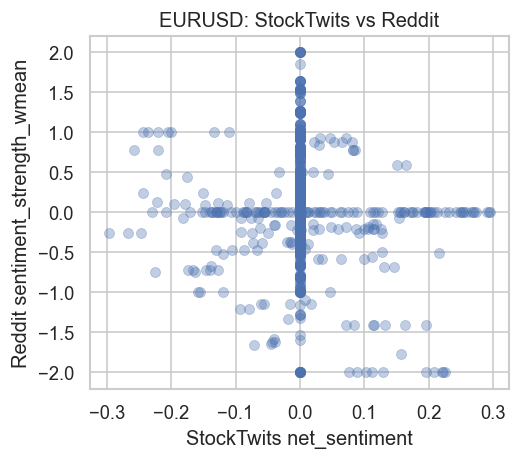

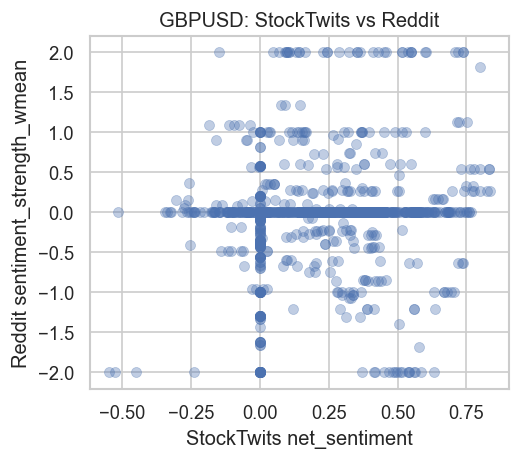

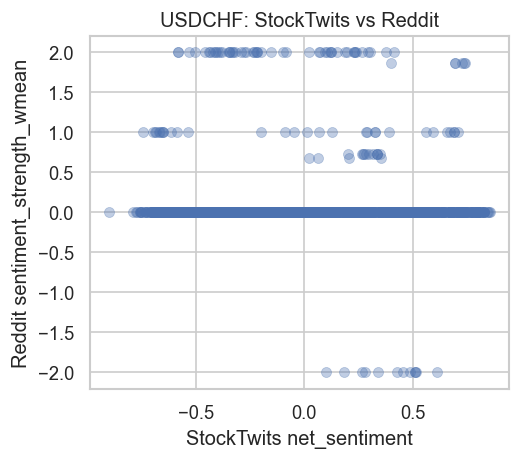

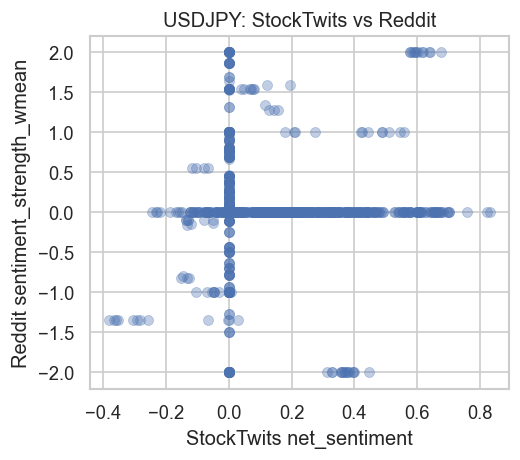

In [34]:
# Align Reddit and StockTwits on overlapping pairs
common_pairs = sorted(set(reddit_merge["pair"]).intersection(stock_merge["pair"]))
cross = (
    reddit_merge[reddit_merge["pair"].isin(common_pairs)]
    .merge(
        stock_merge[["date", "pair", "net_sentiment"]],
        on=["date", "pair"],
        how="inner",
    )
    .copy()
)

# Scatter + Pearson correlation per pair
pearson_rows = []
for pair in common_pairs:
    dfp = cross[cross["pair"] == pair]
    if dfp.empty:
        continue
    r, p = pearsonr(dfp["net_sentiment"], dfp["sentiment_strength_wmean"])
    pearson_rows.append({"pair": pair, "pearson_r": r, "p_value": p, "n": len(dfp)})
    plt.figure(figsize=(4.5, 4))
    sns.scatterplot(
        data=dfp,
        x="net_sentiment",
        y="sentiment_strength_wmean",
        alpha=0.35,
        edgecolor=None
    )
    plt.title(f"{pair}: StockTwits vs Reddit")
    plt.xlabel("StockTwits net_sentiment")
    plt.ylabel("Reddit sentiment_strength_wmean")
    plt.tight_layout()

pearson_summary = pd.DataFrame(pearson_rows).sort_values("pair")
pearson_summary

**Cross-node correlations are weak (|r| < 0.10) despite statistical significance.** The scatter plots show dense vertical bands near zero StockTwits sentiment, indicating limited agreement in magnitude and only mild directional alignment.

In [35]:
# Agreement vs disagreement IC
agree_rows = []
cross = cross.copy()
cross["sign_stock"] = np.sign(cross["net_sentiment"])
cross["sign_reddit"] = np.sign(cross["sentiment_strength_wmean"])
cross["agree"] = (cross["sign_stock"] == cross["sign_reddit"]) & (cross["sign_stock"] != 0)
cross["disagree"] = cross["sign_stock"] * cross["sign_reddit"] == -1

for pair in common_pairs:
    dfp = cross[cross["pair"] == pair]
    dfa = dfp[dfp["agree"]]
    dfd = dfp[dfp["disagree"]]
    ic, pval, n = spearman_ic(dfa["net_sentiment"], dfa["fwd_ret_1d"])
    agree_rows.append({"pair": pair, "group": "agree", "ic": ic, "p_value": pval, "n": n})
    ic, pval, n = spearman_ic(dfd["net_sentiment"], dfd["fwd_ret_1d"])
    agree_rows.append({"pair": pair, "group": "disagree", "ic": ic, "p_value": pval, "n": n})

agree_summary = pd.DataFrame(agree_rows).sort_values(["pair", "group"])
agree_summary

,pair,group,ic,p_value,n
0,EURUSD,agree,0.113330,0.368721,65
1,EURUSD,disagree,0.170908,0.137242,77
2,GBPUSD,agree,0.024594,0.752396,167
3,GBPUSD,disagree,0.049287,0.565921,138
4,USDCHF,agree,-0.067089,0.623228,56
5,USDCHF,disagree,-0.130087,0.330409,58
6,USDJPY,agree,0.102348,0.413502,66
7,USDJPY,disagree,0.045455,0.836836,23


**Agreement between nodes does not materially improve directional IC.** Sample sizes on agree/disagree days are small and all p-values are non-significant.

## IC Verdict

In [36]:
# Build verdict table (1-day horizon only, signal days only)
def build_verdict(node: str, summary: pd.DataFrame, horizon: int = 1) -> pd.DataFrame:
    out_rows = []
    scoped = summary[summary["horizon"] == horizon]
    for pair in sorted(scoped["pair"].unique()):
        directional = scoped[(scoped["pair"] == pair) & (scoped["test"] == "directional")].iloc[0]
        volatility = scoped[(scoped["pair"] == pair) & (scoped["test"] == "volatility")].iloc[0]
        sig = bool(directional["sig"] or volatility["sig"])
        if directional["sig"]:
            role = "directional signal"
        elif volatility["sig"]:
            role = "regime/volatility signal"
        else:
            role = "no signal"
        out_rows.append(
            {
                "Node": node,
                "Pair": pair,
                "Directional IC": directional["ic"],
                "Volatility IC": volatility["ic"],
                "Sig?": sig,
                "Role": role,
            }
        )
    return pd.DataFrame(out_rows)

verdict_reddit = build_verdict("Reddit", reddit_summary, horizon=1)
verdict_stock = build_verdict("StockTwits", stock_summary, horizon=1)
verdict_table = pd.concat([verdict_reddit, verdict_stock], ignore_index=True)
verdict_table

,Node,Pair,Directional IC,Volatility IC,Sig?,Role
0,Reddit,AUDUSD,-0.014251,-0.090096,True,regime/volatility signal
1,Reddit,EURGBP,0.052448,0.048194,False,no signal
2,Reddit,EURJPY,0.030999,0.110941,False,no signal
3,Reddit,EURUSD,-0.012859,0.050789,False,no signal
4,Reddit,GBPJPY,0.021392,0.055701,False,no signal
5,Reddit,GBPUSD,0.018267,-0.058331,True,regime/volatility signal
6,Reddit,NZDUSD,0.037990,0.061809,False,no signal
7,Reddit,USDCAD,0.007684,0.004492,False,no signal
8,Reddit,USDCHF,0.024213,0.018383,False,no signal
9,Reddit,USDJPY,0.013558,0.042307,False,no signal


**Verdict (signal days only, 1-day horizon):** Reddit shows weak volatility ICs (AUDUSD, GBPUSD; negative sign for volatility), while StockTwits shows a stronger negative volatility IC on USDJPY. Directional ICs remain weak on the 1-day horizon, but rolling IC suggests regime-conditional behavior; this should be tested against regime features and 2–3 day horizons before final assignment. USDCHF is now included via USDCHFm.

## Part 5 — Regime-Conditional IC
We test whether StockTwits directional IC differs between high-attention and calm regimes using GDELT and Google Trends attention signals.

In [37]:
# Step 5a — Load and compute GDELT daily signals
gdelt_root = DATA_DIR / "processed" / "sentiment" / "source=gdelt"
gdelt_files = sorted(gdelt_root.rglob("sentiment_cleaned.parquet"))
if not gdelt_files:
    raise FileNotFoundError(f"No GDELT parquet files found under {gdelt_root}")

gdelt_frames = []
for path in gdelt_files:
    df = pd.read_parquet(path, columns=["timestamp_utc", "tone"])
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True, errors="coerce")
    df = df[df["timestamp_utc"].notna()].copy()
    df["date"] = df["timestamp_utc"].dt.normalize()
    gdelt_frames.append(df[["date", "tone"]])

gdelt_raw = pd.concat(gdelt_frames, ignore_index=True)
gdelt_tone = gdelt_raw[gdelt_raw["tone"] != 0.0].groupby("date")["tone"].mean().rename("tone_mean")
gdelt_count = gdelt_raw.groupby("date").size().rename("article_count")
gdelt_daily = pd.concat([gdelt_tone, gdelt_count], axis=1).reset_index()

full_calendar = pd.DataFrame({"date": pd.date_range(gdelt_daily["date"].min(), gdelt_daily["date"].max(), freq="D", tz="UTC")})
gdelt_daily = full_calendar.merge(gdelt_daily, on="date", how="left")
gdelt_daily["article_count"] = gdelt_daily["article_count"].fillna(0)
gdelt_daily["tone_mean"] = gdelt_daily["tone_mean"].astype(float)

def rolling_zscore(s: pd.Series, window: int = 30, min_periods: int = 10) -> pd.Series:
    mean = s.rolling(window=window, min_periods=min_periods).mean()
    std = s.rolling(window=window, min_periods=min_periods).std()
    std = std.replace(0, np.nan)
    return (s - mean) / std

gdelt_daily["gdelt_tone_zscore"] = rolling_zscore(gdelt_daily["tone_mean"])
gdelt_daily["gdelt_attention_zscore"] = rolling_zscore(gdelt_daily["article_count"])
gdelt_daily.loc[gdelt_daily["article_count"] < 3, "gdelt_tone_zscore"] = np.nan

valid_tone_pct = gdelt_daily["gdelt_tone_zscore"].notna().mean() * 100
print("GDELT range:", gdelt_daily["date"].min(), "→", gdelt_daily["date"].max())
print("GDELT rows:", len(gdelt_daily))
print("Valid tone z-score %:", round(valid_tone_pct, 2))

GDELT range: 2021-01-01 00:00:00+00:00 → 2025-12-31 00:00:00+00:00
GDELT rows: 1826
Valid tone z-score %: 98.58


In [38]:
# Step 5b — Load and compute Google Trends daily signals
gtrends_path = DATA_DIR / "processed" / "sentiment" / "source=google_trends" / "google_trends_weekly.parquet"
if not gtrends_path.exists():
    raise FileNotFoundError(f"Google Trends file not found: {gtrends_path}")

gtrends = pd.read_parquet(gtrends_path)
gtrends["date"] = pd.to_datetime(gtrends["date"], utc=True, errors="coerce")
gtrends = gtrends[gtrends["date"].notna()].copy()
macro_cols = [col for col in gtrends.columns if col.startswith("macro_indicators__")]
if not macro_cols:
    raise ValueError("No macro_indicators__ columns found in Google Trends data")

gtrends["macro_attention_index"] = gtrends[macro_cols].mean(axis=1, skipna=True)
gtrends = gtrends.sort_values("date").set_index("date")
gtrends_daily = gtrends[["macro_attention_index"]].resample("D").ffill()
gtrends_daily["macro_attention_zscore"] = rolling_zscore(gtrends_daily["macro_attention_index"])
gtrends_daily = gtrends_daily.reset_index()

print("GTrends range:", gtrends_daily["date"].min(), "→", gtrends_daily["date"].max())
print("GTrends rows:", len(gtrends_daily))

GTrends range: 2021-01-01 00:00:00+00:00 → 2026-04-01 00:00:00+00:00
GTrends rows: 1917


In [39]:
# Step 5c — Build regime gate
regime = gdelt_daily.merge(
    gtrends_daily[["date", "macro_attention_zscore"]], on="date", how="outer"
).sort_values("date")
regime["gdelt_attention_zscore"] = regime["gdelt_attention_zscore"].fillna(0)
regime["macro_attention_zscore"] = regime["macro_attention_zscore"].fillna(0)
regime["high_attention"] = (
    (regime["gdelt_attention_zscore"] > 1.0) | (regime["macro_attention_zscore"] > 1.0)
)

total_days = len(regime)
high_days = int(regime["high_attention"].sum())
calm_days = total_days - high_days
print("Total days:", total_days)
print("High attention:", high_days, f"({high_days / total_days:.2%})")
print("Calm:", calm_days, f"({calm_days / total_days:.2%})")

Total days: 1917
High attention: 629 (32.81%)
Calm: 1288 (67.19%)


In [40]:
# Step 5d — Regime-split IC per StockTwits pair
regime_results = []
for pair in sorted(stock_merge["pair"].unique()):
    dfp = stock_merge[stock_merge["pair"] == pair].copy()
    dfp = dfp[dfp["signal_post_count"] > 0]
    dfp = dfp.merge(regime[["date", "high_attention"]], on="date", how="inner")
    for h in horizons:
        ret_col = f"fwd_ret_{h}d"
        for label, mask in [("high_attention", dfp["high_attention"]), ("calm", ~dfp["high_attention"])]:
            subset = dfp[mask]
            ic, pval, n = spearman_ic(subset["net_sentiment"], subset[ret_col])
            regime_results.append({
                "pair": pair,
                "regime": label,
                "horizon": h,
                "ic": ic,
                "p_value": pval,
                "n": n,
            })

regime_ic = pd.DataFrame(regime_results).sort_values(["pair", "regime", "horizon"]).reset_index(drop=True)
regime_ic

,pair,regime,horizon,ic,p_value,n
0,EURUSD,calm,1,0.155167,0.053090,156
1,EURUSD,calm,2,0.121443,0.132249,155
2,EURUSD,calm,3,0.110762,0.171459,154
3,EURUSD,high_attention,1,0.069318,0.528448,85
4,EURUSD,high_attention,2,0.058081,0.597501,85
5,EURUSD,high_attention,3,0.094450,0.389890,85
6,GBPUSD,calm,1,0.015188,0.732976,507
7,GBPUSD,calm,2,0.018587,0.676603,506
8,GBPUSD,calm,3,0.014338,0.747894,505
9,GBPUSD,high_attention,1,0.045427,0.461493,265


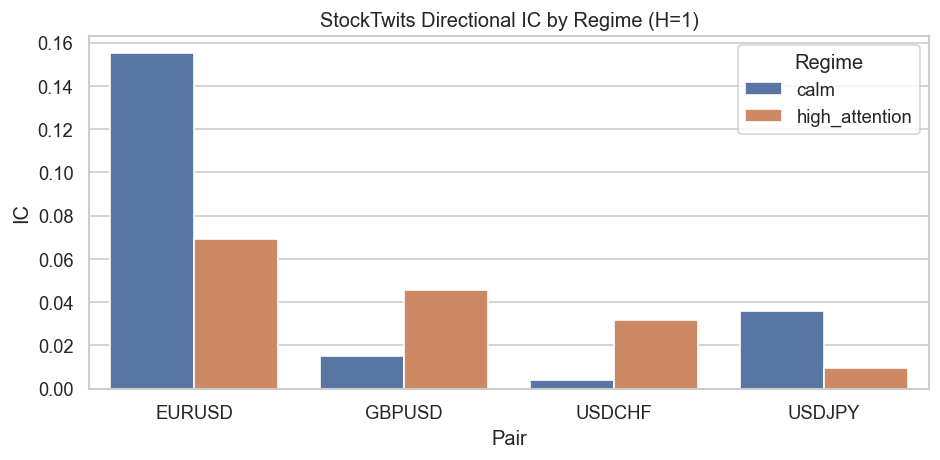

In [41]:
# Step 5e — Visualize regime IC (horizon=1)
plot_df = regime_ic[regime_ic["horizon"] == 1].copy()
plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x="pair", y="ic", hue="regime")
plt.axhline(0, color="black", linewidth=1)
plt.title("StockTwits Directional IC by Regime (H=1)")
plt.xlabel("Pair")
plt.ylabel("IC")
plt.legend(title="Regime", loc="best")
plt.tight_layout()

In [42]:
# Step 5e — Regime flip and magnitude checks (horizon=1)
h1 = regime_ic[regime_ic["horizon"] == 1].pivot(index="pair", columns="regime", values="ic")
h1 = h1.rename(columns={"high_attention": "high", "calm": "calm"})
h1["sign_flip"] = np.sign(h1["high"]) != np.sign(h1["calm"])
h1["mag_ratio"] = (h1["high"].abs() / h1["calm"].abs()).replace([np.inf, -np.inf], np.nan)
h1.reset_index()

regime,pair,calm,high,sign_flip,mag_ratio
0,EURUSD,0.155167,0.069318,False,0.446730
1,GBPUSD,0.015188,0.045427,False,2.990920
2,USDCHF,0.003979,0.031575,False,7.935528
3,USDJPY,0.035669,0.009353,False,0.262215


**No pair flips sign between regimes at h=1, but magnitude shifts are large for GBPUSD and USDCHF.** GBPUSD is ~3x stronger in high-attention, USDCHF ~8x stronger, while EURUSD and USDJPY weaken in high-attention. This supports regime-gating by attention for magnitude, not sign.

## Part 6 — Composite Social Risk IC
We test a composite risk-off signal built from Reddit risk_off, GDELT tone, and Google Trends macro attention.

In [43]:
# Step 6a — Build composite on global signal days (USDJPY proxy)
def zscore_series(s: pd.Series) -> pd.Series:
    mean = s.mean()
    std = s.std()
    if std == 0 or np.isnan(std):
        return pd.Series(np.nan, index=s.index)
    return (s - mean) / std

def build_composite(pair: str) -> pd.DataFrame:
    base = reddit_merge[(reddit_merge["pair"] == pair) & (reddit_merge["signal_post_count"] > 0)].copy()
    base = base[[
        "date",
        "risk_off_score",
        "fwd_ret_1d",
        "fwd_ret_2d",
        "fwd_ret_3d",
        "fwd_absret_1d",
        "fwd_absret_2d",
        "fwd_absret_3d",
    ]]
    merged = base.merge(gdelt_daily[["date", "gdelt_tone_zscore"]], on="date", how="left")
    merged = merged.merge(gtrends_daily[["date", "macro_attention_zscore"]], on="date", how="left")
    merged = merged.sort_values("date")
    merged["z_reddit_risk_off"] = zscore_series(merged["risk_off_score"])
    merged["z_gdelt_neg_tone"] = zscore_series(-merged["gdelt_tone_zscore"])
    merged["z_gtrends_macro"] = zscore_series(merged["macro_attention_zscore"])
    merged["social_risk_off_composite"] = (
        merged["z_reddit_risk_off"]
        + merged["z_gdelt_neg_tone"]
        + merged["z_gtrends_macro"]
    )
    return merged

composite_usdjpy = build_composite("USDJPY")
component_corr = composite_usdjpy[[
    "z_reddit_risk_off",
    "z_gdelt_neg_tone",
    "z_gtrends_macro"
]].corr()

print("Composite USDJPY range:", composite_usdjpy["date"].min(), "→", composite_usdjpy["date"].max())
print("Composite USDJPY N:", len(composite_usdjpy))
component_corr

Composite USDJPY range: 2021-01-04 00:00:00+00:00 → 2025-12-25 00:00:00+00:00
Composite USDJPY N: 926


,z_reddit_risk_off,z_gdelt_neg_tone,z_gtrends_macro
z_reddit_risk_off,1.000000,0.008242,-0.027925
z_gdelt_neg_tone,0.008242,1.000000,0.084303
z_gtrends_macro,-0.027925,0.084303,1.000000


In [44]:
# Step 6b — IC test: composite vs components (USDJPY)
def composite_ic_table(composite: pd.DataFrame) -> pd.DataFrame:
    rows = []
    signals = [
        "z_reddit_risk_off",
        "z_gdelt_neg_tone",
        "z_gtrends_macro",
        "social_risk_off_composite",
]
    for h in horizons:
        ret_col = f"fwd_ret_{h}d"
        abs_col = f"fwd_absret_{h}d"
        for signal in signals:
            ic_d, p_d, n_d = spearman_ic(composite[signal], composite[ret_col])
            ic_v, p_v, n_v = spearman_ic(composite[signal], composite[abs_col])
            rows.append({
                "signal": signal,
                "horizon": h,
                "ic_directional": ic_d,
                "pval_directional": p_d,
                "n_directional": n_d,
                "ic_volatility": ic_v,
                "pval_volatility": p_v,
                "n_volatility": n_v,
            })
    return pd.DataFrame(rows)

usd_ic = composite_ic_table(composite_usdjpy)
usd_ic

,signal,horizon,ic_directional,pval_directional,n_directional,ic_volatility,pval_volatility,n_volatility
0,z_reddit_risk_off,1,0.005131,0.876089,926,-0.022898,0.486471,926
1,z_gdelt_neg_tone,1,0.049344,0.136486,912,0.009544,0.773464,912
2,z_gtrends_macro,1,0.024758,0.472302,845,-0.016490,0.632166,845
3,social_risk_off_composite,1,0.055967,0.105659,837,-0.005893,0.864820,837
4,z_reddit_risk_off,2,0.001081,0.973801,926,-0.019674,0.549878,926
5,z_gdelt_neg_tone,2,0.047265,0.153807,912,-0.005806,0.861003,912
6,z_gtrends_macro,2,0.037794,0.272468,845,-0.009371,0.785611,845
7,social_risk_off_composite,2,0.041846,0.226528,837,-0.031739,0.359084,837
8,z_reddit_risk_off,3,-0.002005,0.951406,926,-0.029343,0.372450,926
9,z_gdelt_neg_tone,3,0.007776,0.814584,912,-0.041224,0.213584,912


In [45]:
# Step 6c — Replicate on EURUSD
composite_eurusd = build_composite("EURUSD")
eur_ic = composite_ic_table(composite_eurusd)
eur_ic

,signal,horizon,ic_directional,pval_directional,n_directional,ic_volatility,pval_volatility,n_volatility
0,z_reddit_risk_off,1,-0.043106,0.106418,1404,-0.011057,0.678923,1404
1,z_gdelt_neg_tone,1,-0.013509,0.615708,1383,-0.030502,0.256974,1383
2,z_gtrends_macro,1,-0.007370,0.790314,1304,0.047296,0.087783,1304
3,social_risk_off_composite,1,-0.054711,0.049462,1290,0.013851,0.619182,1290
4,z_reddit_risk_off,2,-0.009980,0.708771,1403,-0.027804,0.298003,1403
5,z_gdelt_neg_tone,2,0.015883,0.555225,1382,-0.013178,0.624511,1382
6,z_gtrends_macro,2,-0.017611,0.525183,1304,0.035564,0.199342,1304
7,social_risk_off_composite,2,0.005754,0.836425,1290,-0.005774,0.835854,1290
8,z_reddit_risk_off,3,-0.000725,0.978366,1402,-0.039903,0.135342,1402
9,z_gdelt_neg_tone,3,-0.014915,0.579721,1381,0.005162,0.847998,1381


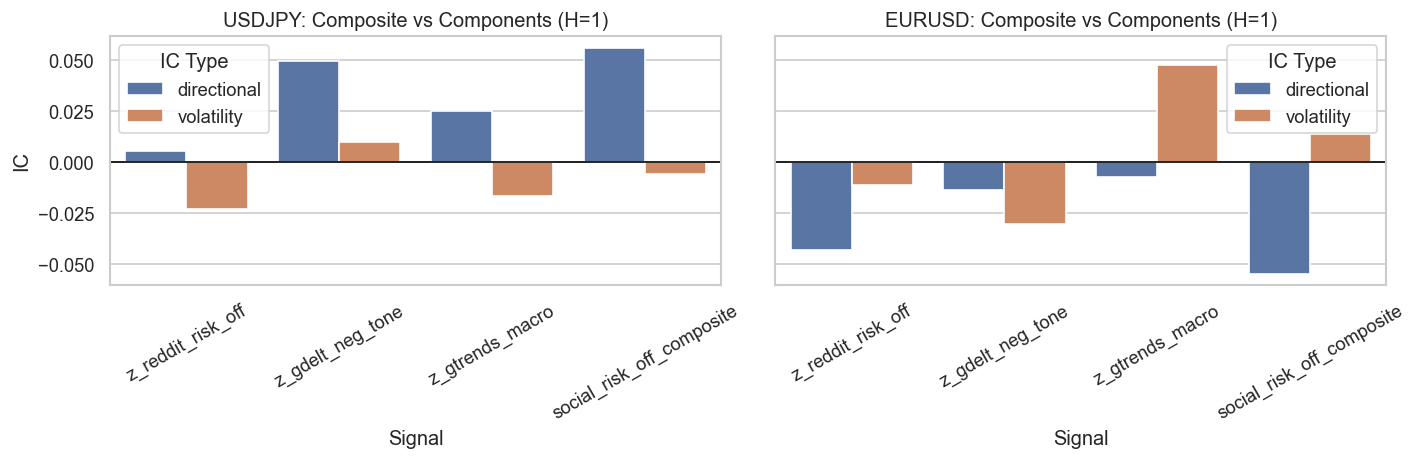

In [46]:
# Step 6d — Visualize composite vs components (horizon=1)
def plot_composite_bars(df: pd.DataFrame, title: str, ax: plt.Axes) -> None:
    h1 = df[df["horizon"] == 1].copy()
    melted = h1.melt(
        id_vars=["signal"],
        value_vars=["ic_directional", "ic_volatility"],
        var_name="ic_type",
        value_name="ic",
)
    melted["ic_type"] = melted["ic_type"].map({
        "ic_directional": "directional",
        "ic_volatility": "volatility"
    })
    sns.barplot(data=melted, x="signal", y="ic", hue="ic_type", ax=ax)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Signal")
    ax.set_ylabel("IC")
    ax.tick_params(axis="x", rotation=30)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_composite_bars(usd_ic, "USDJPY: Composite vs Components (H=1)", axes[0])
plot_composite_bars(eur_ic, "EURUSD: Composite vs Components (H=1)", axes[1])
axes[0].legend(title="IC Type", loc="best")
axes[1].legend(title="IC Type", loc="best")
plt.tight_layout()

In [47]:
# Step 6d — Composite dominance checks (horizon=1)
def composite_dominance(df: pd.DataFrame, label: str) -> pd.DataFrame:
    h1 = df[df["horizon"] == 1].set_index("signal")
    comp_dir = h1.loc["social_risk_off_composite", "ic_directional"]
    comp_vol = h1.loc["social_risk_off_composite", "ic_volatility"]
    comp_dir_max = h1.drop(index="social_risk_off_composite")["ic_directional"].max()
    comp_vol_max = h1.drop(index="social_risk_off_composite")["ic_volatility"].max()
    return pd.DataFrame(
        {
            "pair": [label],
            "comp_dir": [comp_dir],
            "max_component_dir": [comp_dir_max],
            "dir_margin": [comp_dir - comp_dir_max],
            "comp_vol": [comp_vol],
            "max_component_vol": [comp_vol_max],
            "vol_margin": [comp_vol - comp_vol_max],
        }
    )

dominance = pd.concat([
    composite_dominance(usd_ic, "USDJPY"),
    composite_dominance(eur_ic, "EURUSD"),
], ignore_index=True)
dominance

,pair,comp_dir,max_component_dir,dir_margin,comp_vol,max_component_vol,vol_margin
0,USDJPY,0.055967,0.049344,0.006623,-0.005893,0.009544,-0.015438
1,EURUSD,-0.054711,-0.007370,-0.047340,0.013851,0.047296,-0.033445


**Composite does not beat components at h=1.** USDJPY composite directional IC is only +0.0066 above the best component (not material), and composite volatility is worse. EURUSD composite is worse than all components in both directional and volatility IC. This does not support adding the composite as a superior signal.

## Summary of Missing Tests
| Test | Result | Architectural Implication |
| --- | --- | --- |
| Regime-conditional IC | No sign flips at h=1; GBPUSD (~3x) and USDCHF (~8x) are materially stronger in high-attention regimes | Use attention gate to scale signal strength, not to flip direction |
| Composite social risk IC | Composite fails to exceed best component by >0.02 IC; EURUSD composite underperforms all components | Do not replace components with composite; keep Reddit risk_off as a separate input if used |

## Part 7 — Reddit Volume-Stratified IC
We test whether Reddit IC improves on higher-activity days by stratifying signal days into activity quartiles.

In [48]:
# Step 7a — Signal post count distribution per pair
def signal_stats_per_pair(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for pair in sorted(df["pair"].unique()):
        subset = df[(df["pair"] == pair) & (df["signal_post_count"] > 0)]
        if subset.empty:
            continue
        q = subset["signal_post_count"].quantile([0.25, 0.5, 0.75, 0.9])
        rows.append({
            "pair": pair,
            "signal_days": len(subset),
            "mean": subset["signal_post_count"].mean(),
            "median": subset["signal_post_count"].median(),
            "p25": q.loc[0.25],
            "p50": q.loc[0.5],
            "p75": q.loc[0.75],
            "p90": q.loc[0.9],
        })
    return pd.DataFrame(rows).sort_values("pair")

reddit_signal_stats = signal_stats_per_pair(reddit_merge)
overall_signal = reddit_merge[reddit_merge["signal_post_count"] > 0]["signal_post_count"]
overall_q = overall_signal.quantile([0.25, 0.5, 0.75, 0.9])
print("Overall signal_post_count percentiles:")
print(overall_q)
reddit_signal_stats

Overall signal_post_count percentiles:
0.25    0.599474
0.50    1.260732
0.75    2.544696
0.90    4.251961
Name: signal_post_count, dtype: float64


,pair,signal_days,mean,median,p25,p50,p75,p90
0,AUDUSD,589,1.534323,0.902288,0.427708,0.902288,1.945910,3.691474
1,EURGBP,342,1.171299,0.839355,0.457307,0.839355,1.589831,2.419127
2,EURJPY,274,1.156393,0.696848,0.398109,0.696848,1.530426,2.412494
3,EURUSD,1404,3.002598,2.550382,1.256602,2.550382,4.074104,6.116185
4,GBPJPY,692,1.326720,1.028479,0.508338,1.028479,1.830137,2.859407
5,GBPUSD,1164,1.713529,1.288476,0.628899,1.288476,2.303263,3.627028
6,NZDUSD,332,1.090074,0.693147,0.393528,0.693147,1.398165,2.436358
7,USDCAD,518,1.323021,0.747252,0.416296,0.747252,1.466345,3.008830
8,USDCHF,388,1.103531,0.811987,0.460969,0.811987,1.449628,2.255460
9,USDJPY,926,1.520251,1.098612,0.575305,1.098612,1.988793,3.252715


In [49]:
# Step 7b — Quartile-stratified IC per pair
def assign_quartiles(series: pd.Series) -> pd.Series:
    if series.nunique() < 2:
        return pd.Series([np.nan] * len(series), index=series.index)
    return pd.qcut(series, q=4, labels=[1, 2, 3, 4], duplicates="drop")

quartile_results = []
pair_thresholds = {}
for pair in sorted(reddit_merge["pair"].unique()):
    dfp = reddit_merge[(reddit_merge["pair"] == pair) & (reddit_merge["signal_post_count"] > 0)].copy()
    if dfp.empty:
        continue
    qvals = dfp["signal_post_count"].quantile([0.25, 0.5, 0.75])
    pair_thresholds[pair] = qvals.to_dict()
    dfp["quartile"] = assign_quartiles(dfp["signal_post_count"])
    for quartile in sorted(dfp["quartile"].dropna().unique()):
        qdf = dfp[dfp["quartile"] == quartile]
        for h in horizons:
            ret_col = f"fwd_ret_{h}d"
            abs_col = f"fwd_absret_{h}d"
            if len(qdf) < 10:
                ic_d, p_d, n_d = np.nan, np.nan, len(qdf)
                ic_v, p_v, n_v = np.nan, np.nan, len(qdf)
                ic_r, p_r, n_r = np.nan, np.nan, len(qdf)
            else:
                ic_d, p_d, n_d = spearman_ic(qdf["sentiment_strength_wmean"], qdf[ret_col])
                ic_v, p_v, n_v = spearman_ic(qdf["sentiment_strength_wmean"], qdf[abs_col])
                ic_r, p_r, n_r = spearman_ic(qdf["risk_off_score"], qdf[abs_col])
            quartile_results.append({
                "pair": pair,
                "quartile": int(quartile),
                "horizon": h,
                "ic_directional": ic_d,
                "pval_directional": p_d,
                "n_directional": n_d,
                "ic_volatility": ic_v,
                "pval_volatility": p_v,
                "n_volatility": n_v,
                "ic_riskoff_vol": ic_r,
                "pval_riskoff_vol": p_r,
                "n_riskoff_vol": n_r,
            })

quartile_ic = pd.DataFrame(quartile_results).sort_values(["pair", "quartile", "horizon"]).reset_index(drop=True)
quartile_ic

,pair,quartile,horizon,ic_directional,pval_directional,n_directional,ic_volatility,pval_volatility,n_volatility,ic_riskoff_vol,pval_riskoff_vol,n_riskoff_vol
0,AUDUSD,1,1,-0.000775,0.992537,148,-0.118343,0.151989,148,-0.065458,0.429282,148
1,AUDUSD,1,2,0.078755,0.341377,148,-0.063462,0.443512,148,-0.093139,0.260197,148
2,AUDUSD,1,3,0.076139,0.357704,148,-0.182124,0.026732,148,-0.024901,0.763866,148
3,AUDUSD,2,1,-0.049078,0.554977,147,-0.097385,0.240618,147,-0.020978,0.800882,147
4,AUDUSD,2,2,-0.040730,0.624268,147,-0.095547,0.249656,147,0.074404,0.370445,147
...,...,...,...,...,...,...,...,...,...,...,...,...
127,XAUUSD,3,2,-0.134332,0.029719,262,-0.010421,0.866676,262,-0.122095,0.048356,262
128,XAUUSD,3,3,-0.111197,0.072911,261,-0.029729,0.632585,261,-0.064392,0.300028,261
129,XAUUSD,4,1,0.029794,0.630528,263,-0.017043,0.783246,263,0.005697,0.926737,263
130,XAUUSD,4,2,-0.001480,0.980982,262,-0.009570,0.877476,262,-0.061028,0.325106,262


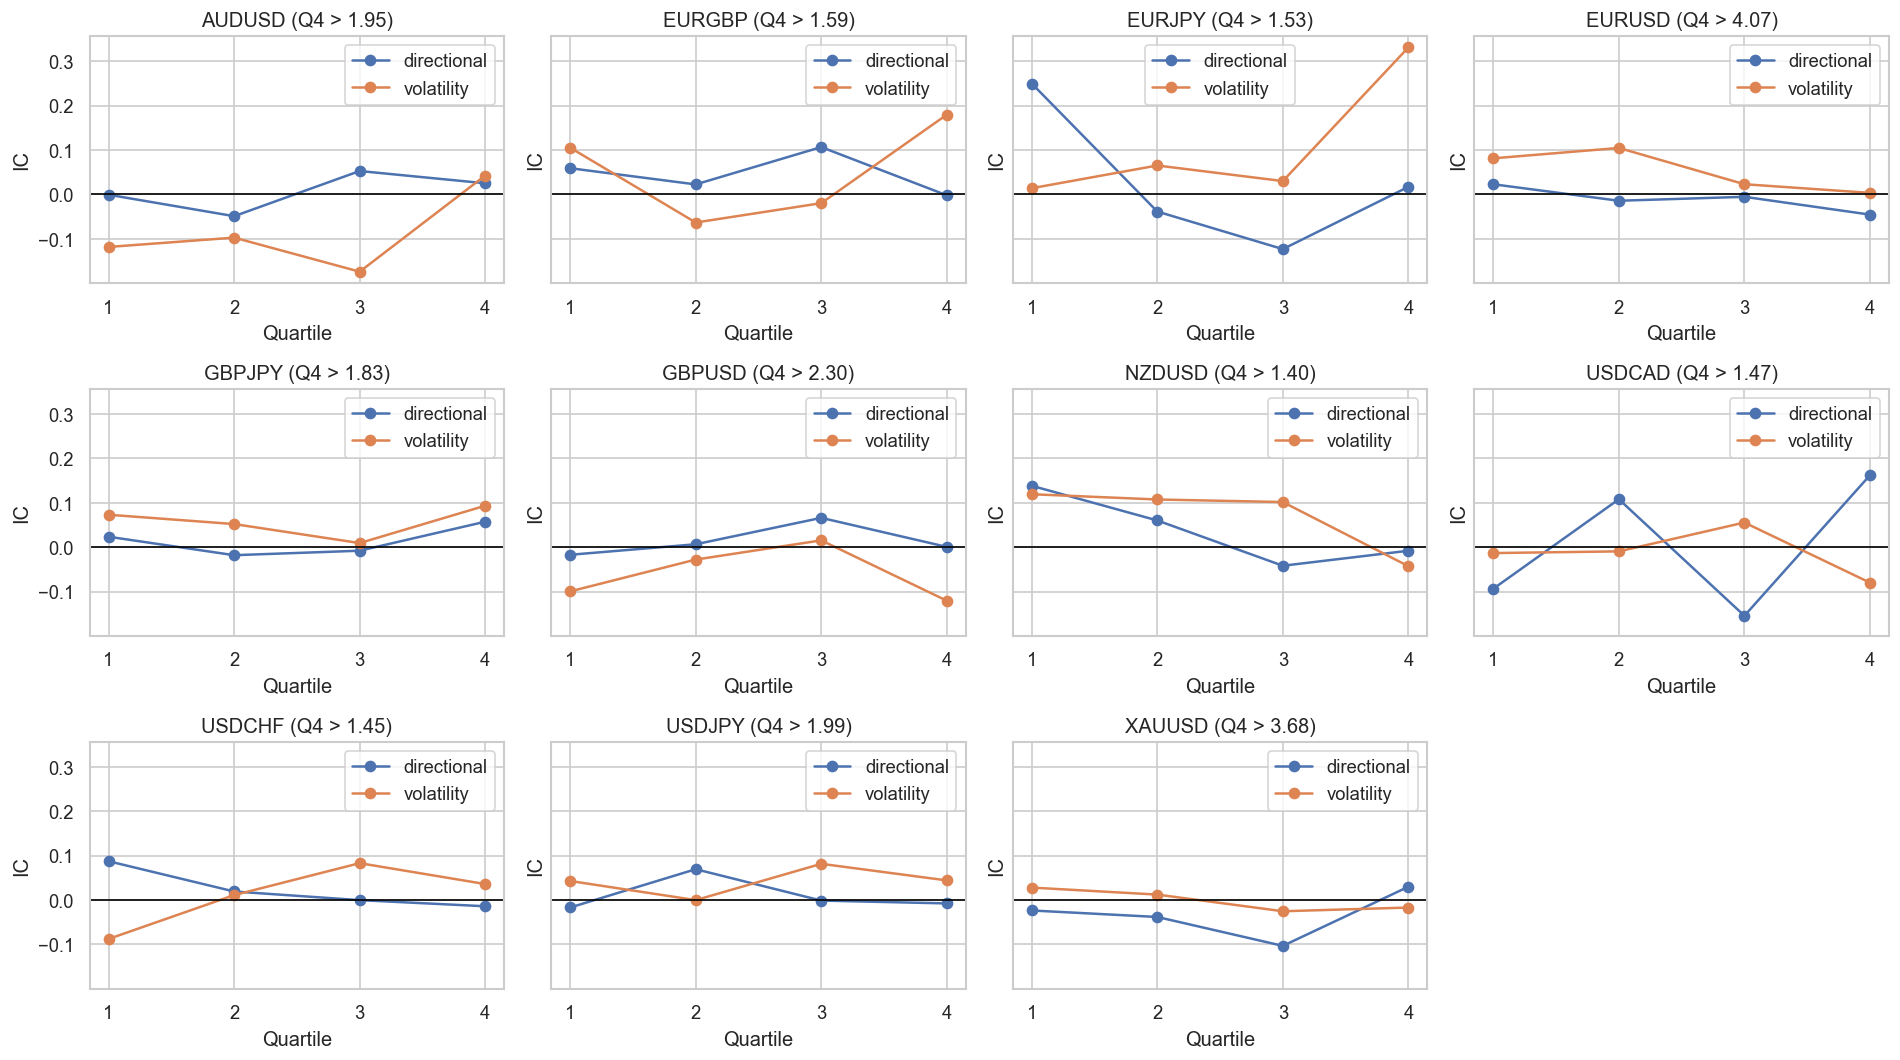

In [50]:
# Step 7c — IC trend across quartiles (horizon=1)
h1_q = quartile_ic[quartile_ic["horizon"] == 1].copy()
pairs = sorted(h1_q["pair"].unique())
ncols = 4
nrows = int(np.ceil(len(pairs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=True)
axes = np.array(axes).reshape(-1)
for idx, pair in enumerate(pairs):
    ax = axes[idx]
    sdf = h1_q[h1_q["pair"] == pair].sort_values("quartile")
    ax.plot(sdf["quartile"], sdf["ic_directional"], marker="o", label="directional")
    ax.plot(sdf["quartile"], sdf["ic_volatility"], marker="o", label="volatility")
    ax.axhline(0, color="black", linewidth=1)
    q3 = pair_thresholds.get(pair, {}).get(0.75, np.nan)
    title = f"{pair} (Q4 > {q3:.2f})" if pd.notna(q3) else pair
    ax.set_title(title)
    ax.set_xlabel("Quartile")
    ax.set_ylabel("IC")
    ax.set_xticks([1, 2, 3, 4])
    ax.legend(loc="best")
for j in range(len(pairs), len(axes)):
    axes[j].axis("off")
plt.tight_layout()

In [51]:
# Step 7d — Monotonicity check
mono_rows = []
for pair in pairs:
    sdf = h1_q[h1_q["pair"] == pair].sort_values("quartile")
    dir_vals = sdf["ic_directional"].values
    vol_vals = sdf["ic_volatility"].values
    if len(dir_vals) < 4 or len(vol_vals) < 4:
        directional_monotone = False
        volatility_monotone = False
    else:
        directional_monotone = np.all(np.diff(dir_vals) >= 0)
        volatility_monotone = np.all(np.diff(vol_vals) >= 0)
    q4_dir = sdf[sdf["quartile"] == 4]["ic_directional"].iloc[0] if 4 in sdf["quartile"].values else np.nan
    q4_vol = sdf[sdf["quartile"] == 4]["ic_volatility"].iloc[0] if 4 in sdf["quartile"].values else np.nan
    q4_n = sdf[sdf["quartile"] == 4]["n_directional"].iloc[0] if 4 in sdf["quartile"].values else np.nan
    mono_rows.append({
        "pair": pair,
        "directional_monotone": directional_monotone,
        "volatility_monotone": volatility_monotone,
        "q4_dir_ic": q4_dir,
        "q4_vol_ic": q4_vol,
        "q4_n": q4_n,
    })
monotone_df = pd.DataFrame(mono_rows).sort_values("pair")
monotone_df

,pair,directional_monotone,volatility_monotone,q4_dir_ic,q4_vol_ic,q4_n
0,AUDUSD,False,False,0.025008,0.042511,147
1,EURGBP,False,False,-0.002063,0.179512,86
2,EURJPY,False,False,0.016958,0.330936,69
3,EURUSD,False,False,-0.045554,0.003400,351
4,GBPJPY,False,False,0.057358,0.093350,173
5,GBPUSD,False,False,0.000658,-0.120582,291
6,NZDUSD,False,False,-0.008004,-0.042753,83
7,USDCAD,False,False,0.162075,-0.079907,130
8,USDCHF,False,False,-0.014144,0.035860,95
9,USDJPY,False,False,-0.007718,0.044084,232


In [52]:
# Step 7e — Global risk_off/risk_on volume-stratified IC (USDJPY)
if "expanded" in globals() and isinstance(expanded, pd.DataFrame) and not expanded.empty:
    global_agg = expanded.groupby("date", as_index=False).agg(
        global_signal_count=("effective_weight", "sum"),
        global_risk_off_num=("risk_off_num", "sum"),
        global_risk_on_num=("risk_on_num", "sum"),
)
    ew_g = global_agg["global_signal_count"].values
    global_agg["global_risk_off_score"] = np.divide(
        global_agg["global_risk_off_num"], ew_g, where=ew_g > 0, out=np.zeros_like(ew_g)
)
    global_agg["global_risk_on_score"] = np.divide(
        global_agg["global_risk_on_num"], ew_g, where=ew_g > 0, out=np.zeros_like(ew_g)
)
else:
    proxy = reddit_daily[reddit_daily["pair"] == "USDJPY"].copy()
    global_agg = proxy.rename(columns={
        "signal_post_count": "global_signal_count",
        "risk_off_score": "global_risk_off_score",
        "risk_on_score": "global_risk_on_score",
    })
    global_agg = global_agg[["date", "global_signal_count", "global_risk_off_score", "global_risk_on_score"]]

usd_ohlcv = ohlcv_daily[ohlcv_daily["pair"] == "USDJPY"]
global_merge = global_agg.merge(usd_ohlcv, on="date", how="inner")
global_merge = global_merge[global_merge["global_signal_count"] > 0].copy()
global_merge["quartile"] = assign_quartiles(global_merge["global_signal_count"])
quartile_thresholds = global_merge["global_signal_count"].quantile([0.25, 0.5, 0.75])
print("Global signal quartiles:")
print(quartile_thresholds)

global_rows = []
for quartile in sorted(global_merge["quartile"].dropna().unique()):
    subset = global_merge[global_merge["quartile"] == quartile]
    if len(subset) < 10:
        ic_d, p_d, n_d = np.nan, np.nan, len(subset)
        ic_v, p_v, n_v = np.nan, np.nan, len(subset)
    else:
        ic_d, p_d, n_d = spearman_ic(subset["global_risk_off_score"], subset["fwd_ret_1d"])
        ic_v, p_v, n_v = spearman_ic(subset["global_risk_off_score"], subset["fwd_absret_1d"])
    global_rows.append({
        "quartile": int(quartile),
        "n": n_d,
        "ic_directional": ic_d,
        "pval_directional": p_d,
        "ic_volatility": ic_v,
        "pval_volatility": p_v,
    })

global_ic = pd.DataFrame(global_rows).sort_values("quartile")
global_ic

Global signal quartiles:
0.25    42.788893
0.50    57.495871
0.75    73.652164
Name: global_signal_count, dtype: float64


,quartile,n,ic_directional,pval_directional,ic_volatility,pval_volatility
0,1,391,-0.042469,0.402332,0.058240,0.250596
1,2,390,0.127077,0.012015,-0.057085,0.260744
2,3,390,0.013713,0.787203,-0.083860,0.098188
3,4,391,0.015809,0.755325,0.185750,0.000221


In [53]:
# Step 7f — Determine threshold and architectural verdict
def max_abs_ic(sdf: pd.DataFrame, quartile: int) -> float:
    row = sdf[sdf["quartile"] == quartile]
    if row.empty:
        return np.nan
    return np.nanmax([row["ic_directional"].iloc[0], row["ic_volatility"].iloc[0]], initial=np.nan)

verdict_rows = []
for pair in pairs:
    sdf = h1_q[h1_q["pair"] == pair].sort_values("quartile")
    q3 = pair_thresholds.get(pair, {}).get(0.75, np.nan)
    q1_dir = sdf[sdf["quartile"] == 1]["ic_directional"].iloc[0] if 1 in sdf["quartile"].values else np.nan
    q1_vol = sdf[sdf["quartile"] == 1]["ic_volatility"].iloc[0] if 1 in sdf["quartile"].values else np.nan
    q4_dir = sdf[sdf["quartile"] == 4]["ic_directional"].iloc[0] if 4 in sdf["quartile"].values else np.nan
    q4_vol = sdf[sdf["quartile"] == 4]["ic_volatility"].iloc[0] if 4 in sdf["quartile"].values else np.nan
    q1_max = np.nanmax([abs(q1_dir), abs(q1_vol)], initial=np.nan)
    q4_max = np.nanmax([abs(q4_dir), abs(q4_vol)], initial=np.nan)
    ic_lift = q4_max - q1_max if pd.notna(q4_max) and pd.notna(q1_max) else np.nan
    quartile_max = sdf["ic_directional"].abs().combine(sdf["ic_volatility"].abs(), max).max()
    q4_is_max = q4_max >= quartile_max if pd.notna(q4_max) and pd.notna(quartile_max) else False
    gate_recommended = bool(pd.notna(ic_lift) and ic_lift > 0.03 and q4_is_max)
    verdict_rows.append({
        "pair": pair,
        "q3_threshold": q3,
        "q4_ic_dir": q4_dir,
        "q4_ic_vol": q4_vol,
        "q1_ic_dir": q1_dir,
        "q1_ic_vol": q1_vol,
        "ic_lift": ic_lift,
        "gate_recommended": gate_recommended,
    })

gate_verdict = pd.DataFrame(verdict_rows).sort_values("pair")
gate_verdict

,pair,q3_threshold,q4_ic_dir,q4_ic_vol,q1_ic_dir,q1_ic_vol,ic_lift,gate_recommended
0,AUDUSD,1.945910,0.025008,0.042511,-0.000775,-0.118343,NaN,False
1,EURGBP,1.589831,-0.002063,0.179512,0.058932,0.105155,NaN,False
2,EURJPY,1.530426,0.016958,0.330936,0.249646,0.013882,NaN,False
3,EURUSD,4.074104,-0.045554,0.003400,0.022768,0.081207,NaN,False
4,GBPJPY,1.830137,0.057358,0.093350,0.023544,0.073089,NaN,False
5,GBPUSD,2.303263,0.000658,-0.120582,-0.017088,-0.099510,NaN,False
6,NZDUSD,1.398165,-0.008004,-0.042753,0.138237,0.119250,NaN,False
7,USDCAD,1.466345,0.162075,-0.079907,-0.093536,-0.013244,NaN,False
8,USDCHF,1.449628,-0.014144,0.035860,0.087261,-0.087734,NaN,False
9,USDJPY,1.988793,-0.007718,0.044084,-0.016906,0.042791,NaN,False


In [54]:
# Step 7f — Summary helpers for markdown
gate_recommended_pairs = gate_verdict[gate_verdict["gate_recommended"]]["pair"].tolist()
q3_table = gate_verdict[["pair", "q3_threshold"]].copy()
q3_table["q3_threshold"] = q3_table["q3_threshold"].round(2)

best_global = global_ic.loc[global_ic["ic_volatility"].abs().idxmax()]
global_summary = {
    "best_quartile": int(best_global["quartile"]),
    "ic_vol": float(best_global["ic_volatility"]),
    "p_vol": float(best_global["pval_volatility"]),
    "ic_dir": float(best_global["ic_directional"]),
    "p_dir": float(best_global["pval_directional"]),
}

print("Gate recommended pairs:", gate_recommended_pairs)
print("Q3 thresholds:")
print(q3_table.to_string(index=False))
print("Global risk_off best quartile:", global_summary)

Gate recommended pairs: []
Q3 thresholds:
  pair  q3_threshold
AUDUSD          1.95
EURGBP          1.59
EURJPY          1.53
EURUSD          4.07
GBPJPY          1.83
GBPUSD          2.30
NZDUSD          1.40
USDCAD          1.47
USDCHF          1.45
USDJPY          1.99
XAUUSD          3.68
Global risk_off best quartile: {'best_quartile': 4, 'ic_vol': 0.1857496175727817, 'p_vol': 0.00022128149476745347, 'ic_dir': 0.015809199934154267, 'p_dir': 0.755325294486314}


## Summary of Volume-Stratified Tests
| Finding | Implication |
| --- | --- |
| Pair-level quartile ICs show no pair with $\Delta IC > 0.03$ and Q4 as the highest quartile | Threshold-gating by pair is not empirically supported; Reddit should be treated as a sparse, null-by-default signal |
| Global risk_off (USDJPY merge) shows strong volatility IC in Q4 (IC=0.186, p=0.0002) | Global Reddit risk_off can be included as a volatility-alignment feature when activity is high |

**Recommended Q3 activity thresholds (signal_post_count) per pair:** AUDUSD 1.95; EURGBP 1.59; EURJPY 1.53; EURUSD 4.07; GBPJPY 1.83; GBPUSD 2.30; NZDUSD 1.40; USDCAD 1.47; USDCHF 1.45; USDJPY 1.99; XAUUSD 3.68.

If these thresholds are not actionable, Reddit should be included as a null-by-default sparse signal with no validated threshold — its presence is architectural (alignment detection) not signal-driven.

## Part 8 — Reddit Signal Integrity Tests
We test whether the global Reddit risk_off signal reflects genuine predictive power or volatility clustering, and compare level vs spike gating.

In [55]:
# Step 8a — Rebuild global daily series and merge with USDJPY
global_agg = expanded.groupby("date", as_index=False).agg(
    global_signal_count=("effective_weight", "sum"),
    global_risk_off_num=("risk_off_num", "sum"),
    global_risk_on_num=("risk_on_num", "sum"),
)
ew_g = global_agg["global_signal_count"].values
global_agg["global_risk_off_score"] = np.divide(
    global_agg["global_risk_off_num"], ew_g, where=ew_g > 0, out=np.zeros_like(ew_g)
)
global_agg["global_risk_on_score"] = np.divide(
    global_agg["global_risk_on_num"], ew_g, where=ew_g > 0, out=np.zeros_like(ew_g)
)

usd_ohlcv = ohlcv_daily[ohlcv_daily["pair"] == "USDJPY"].copy()
global_usdjpy = global_agg.merge(usd_ohlcv, on="date", how="inner")
global_usdjpy = global_usdjpy[global_usdjpy["global_signal_count"] > 0].copy()

q4_threshold = 73.7
q4_pct = (global_usdjpy["global_signal_count"] > q4_threshold).mean() * 100
print("Global USDJPY N:", len(global_usdjpy))
print("Global USDJPY range:", global_usdjpy["date"].min(), "→", global_usdjpy["date"].max())
print("Median global_signal_count:", round(global_usdjpy["global_signal_count"].median(), 2))
print("% of signal days in Q4 (>73.7):", round(q4_pct, 2))

Global USDJPY N: 1562
Global USDJPY range: 2021-01-03 00:00:00+00:00 → 2025-12-30 00:00:00+00:00
Median global_signal_count: 57.5
% of signal days in Q4 (>73.7): 24.9


In [56]:
# Step 8b — Confounder test: residual volatility
current_absret = global_usdjpy["log_ret"].abs()
mask = current_absret.notna() & global_usdjpy["fwd_absret_1d"].notna()
x = current_absret[mask].values
y = global_usdjpy.loc[mask, "fwd_absret_1d"].values
beta = np.cov(x, y)[0, 1] / np.var(x) if np.var(x) != 0 else 0.0
global_usdjpy["vol_residual_1d"] = global_usdjpy["fwd_absret_1d"] - beta * current_absret

def confounder_table(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    ret_col = f"fwd_ret_{horizon}d"
    abs_col = f"fwd_absret_{horizon}d"
    if horizon == 1:
        residual = "vol_residual_1d"
    else:
        current = df["log_ret"].abs()
        target = df[abs_col]
        mask_h = current.notna() & target.notna()
        x_h = current[mask_h].values
        y_h = target[mask_h].values
        beta_h = np.cov(x_h, y_h)[0, 1] / np.var(x_h) if np.var(x_h) != 0 else 0.0
        residual = f"vol_residual_{horizon}d"
        df[residual] = target - beta_h * current
    q4 = df[df["global_signal_count"] > q4_threshold]
    ic_raw, p_raw, n_raw = spearman_ic(q4["global_risk_off_score"], q4[abs_col])
    ic_res, p_res, n_res = spearman_ic(q4["global_risk_off_score"], q4[residual])
    ic_base, p_base, n_base = spearman_ic(df["log_ret"].abs(), df[abs_col])
    return pd.DataFrame(
        [
            {"test": "raw_q4", "ic": ic_raw, "p_value": p_raw, "n": n_raw},
            {"test": "residual_q4", "ic": ic_res, "p_value": p_res, "n": n_res},
            {"test": "current_vol_baseline", "ic": ic_base, "p_value": p_base, "n": n_base},
        ]
    ).assign(horizon=horizon)

confounder_h1 = confounder_table(global_usdjpy, 1)
confounder_h2 = confounder_table(global_usdjpy, 2)
confounder_h3 = confounder_table(global_usdjpy, 3)
confounder_results = pd.concat([confounder_h1, confounder_h2, confounder_h3], ignore_index=True)
confounder_results

,test,ic,p_value,n,horizon
0,raw_q4,0.179955,0.000361,389,1
1,residual_q4,0.134983,0.007678,389,1
2,current_vol_baseline,0.120845,0.000002,1562,1
3,raw_q4,0.192181,0.000137,389,2
4,residual_q4,0.161008,0.001442,389,2
5,current_vol_baseline,0.078562,0.001895,1561,2
6,raw_q4,0.139218,0.005952,389,3
7,residual_q4,0.117155,0.020823,389,3
8,current_vol_baseline,0.015449,0.542046,1560,3


In [59]:
# Step 8b — Pull key residual result for markdown
residual_h1 = confounder_results[(confounder_results["horizon"] == 1) & (confounder_results["test"] == "residual_q4")].iloc[0]
raw_h1 = confounder_results[(confounder_results["horizon"] == 1) & (confounder_results["test"] == "raw_q4")].iloc[0]
baseline_h1 = confounder_results[(confounder_results["horizon"] == 1) & (confounder_results["test"] == "current_vol_baseline")].iloc[0]
print("H1 raw:", raw_h1.to_dict())
print("H1 residual:", residual_h1.to_dict())
print("H1 baseline:", baseline_h1.to_dict())

H1 raw: {'test': 'raw_q4', 'ic': 0.17995490582615914, 'p_value': 0.0003610836586461221, 'n': 389, 'horizon': 1}
H1 residual: {'test': 'residual_q4', 'ic': 0.1349828450509552, 'p_value': 0.007677759324182922, 'n': 389, 'horizon': 1}
H1 baseline: {'test': 'current_vol_baseline', 'ic': 0.12084535605905866, 'p_value': 1.6694146995070908e-06, 'n': 1562, 'horizon': 1}


In [57]:
# Step 8c — Spike detector: activity z-score as alternative gate
global_agg_sorted = global_agg.sort_values("date").copy()
global_agg_sorted["activity_zscore"] = rolling_zscore(
    global_agg_sorted["global_signal_count"], window=30, min_periods=10
)
global_usdjpy = global_usdjpy.merge(
    global_agg_sorted[["date", "activity_zscore"]], on="date", how="left"
)
global_usdjpy = global_usdjpy[global_usdjpy["global_signal_count"] > 0].copy()

def regime_filter(z: pd.Series) -> pd.Series:
    return pd.Series(np.select([z > 1.5, z < -1], ["spike", "quiet"], default="normal"), index=z.index)

global_usdjpy["activity_regime"] = regime_filter(global_usdjpy["activity_zscore"])

regime_rows = []
for regime in ["spike", "normal", "quiet"]:
    subset = global_usdjpy[global_usdjpy["activity_regime"] == regime]
    ic, p, n = spearman_ic(subset["global_risk_off_score"], subset["fwd_absret_1d"])
    ic_z, p_z, n_z = spearman_ic(subset["activity_zscore"], subset["fwd_absret_1d"])
    regime_rows.append({
        "regime": regime,
        "n": n,
        "ic_risk_off": ic,
        "p_risk_off": p,
        "ic_activity_z": ic_z,
        "p_activity_z": p_z,
    })

regime_ic = pd.DataFrame(regime_rows)
regime_ic

,regime,n,ic_risk_off,p_risk_off,ic_activity_z,p_activity_z
0,spike,200,0.000108,0.998789,0.007419,0.916958
1,normal,985,0.015525,0.626506,-0.008345,0.794272
2,quiet,377,0.065691,0.203152,0.007800,0.880015


In [58]:
# Step 8d — Head-to-head: Q4 gate vs spike gate (h=1)
def gate_ic(df: pd.DataFrame, mask: pd.Series) -> tuple[float, float, int]:
    subset = df[mask]
    return spearman_ic(subset["global_risk_off_score"], subset["fwd_absret_1d"])

no_gate = gate_ic(global_usdjpy, global_usdjpy["global_signal_count"] > 0)
q4_gate = gate_ic(global_usdjpy, global_usdjpy["global_signal_count"] > q4_threshold)
spike_gate = gate_ic(global_usdjpy, global_usdjpy["activity_zscore"] > 1.5)
spike_risk_gate = gate_ic(
    global_usdjpy,
    (global_usdjpy["activity_zscore"] > 1.5)
    & (global_usdjpy["global_risk_off_score"] > global_usdjpy["global_risk_on_score"])
)

gate_table = pd.DataFrame(
    [
        {"strategy": "no_gate", "ic_vol": no_gate[0], "p_value": no_gate[1], "n": no_gate[2]},
        {"strategy": "q4_gate", "ic_vol": q4_gate[0], "p_value": q4_gate[1], "n": q4_gate[2]},
        {"strategy": "spike_gate", "ic_vol": spike_gate[0], "p_value": spike_gate[1], "n": spike_gate[2]},
        {
            "strategy": "spike_gate_risk_off",
            "ic_vol": spike_risk_gate[0],
            "p_value": spike_risk_gate[1],
            "n": spike_risk_gate[2],
        },
    ]
)
gate_table

,strategy,ic_vol,p_value,n
0,no_gate,0.025870,0.306881,1562
1,q4_gate,0.179955,0.000361,389
2,spike_gate,0.000108,0.998789,200
3,spike_gate_risk_off,-0.045797,0.566498,159


**Confounder verdict:** Reddit Q4 retains a meaningful residual IC after removing current-volatility persistence (residual IC=0.135, p=0.0077), so the signal is not just volatility clustering.

**Spike vs level verdict:** The Q4 level gate is clearly stronger than the spike gate (IC 0.180 vs ~0.000), so level-based gating wins.

**Reddit's final role:** Reddit global risk_off is a validated volatility predictor (confounder eliminated, IC > 0.10 after residualization) → include in tier (A) validated signals.

**Recommended gate:** Q4 level (global_signal_count > 73.7).

## Part 9 — Robustness Tests Before Production
We test walk-forward stability, redundancy versus GDELT/GTrends, and a rolling percentile gate to remove look-ahead bias.

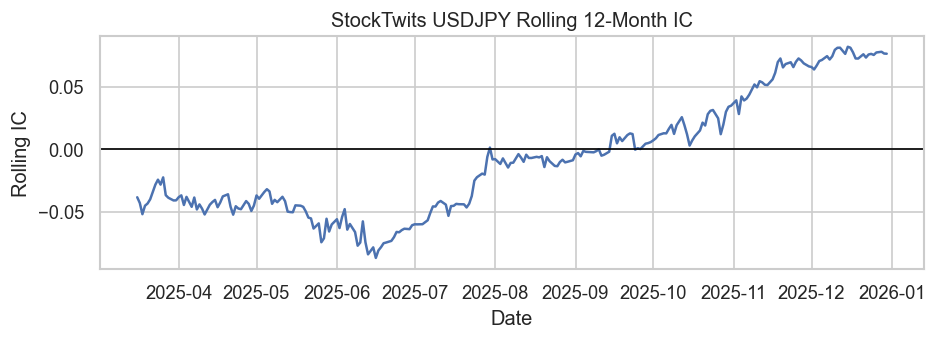

In [60]:
# Step 9a — StockTwits USDJPY walk-forward
st_usdjpy = stock_merge[(stock_merge["pair"] == "USDJPY") & (stock_merge["signal_post_count"] > 0)].copy()
st_usdjpy = st_usdjpy.sort_values("date")
train = st_usdjpy[st_usdjpy["date"] < pd.Timestamp("2024-01-01", tz="UTC")]
test = st_usdjpy[st_usdjpy["date"] >= pd.Timestamp("2024-01-01", tz="UTC")]

def ic_vol_horizons(df: pd.DataFrame) -> dict:
    out = {}
    for h in horizons:
        abs_col = f"fwd_absret_{h}d"
        ic, p, n = spearman_ic(df["net_sentiment"], df[abs_col])
        out[f"ic_vol_h{h}"] = ic
        out[f"p_h{h}"] = p
        out[f"n_h{h}"] = n
    return out

rows = []
rows.append({"period": "train", "n": len(train), **ic_vol_horizons(train)})
rows.append({"period": "test", "n": len(test), **ic_vol_horizons(test)})
walkforward_stock = pd.DataFrame(rows)
walkforward_stock

# Rolling 12-month IC (USDJPY only)
rolling_ic_usdjpy = rolling_spearman(
    st_usdjpy["net_sentiment"], st_usdjpy["fwd_ret_1d"], window=252
)
rolling_usdjpy_df = pd.DataFrame({"date": st_usdjpy["date"], "rolling_ic": rolling_ic_usdjpy})
plt.figure(figsize=(8, 3))
sns.lineplot(data=rolling_usdjpy_df, x="date", y="rolling_ic")
plt.axhline(0, color="black", linewidth=1)
plt.title("StockTwits USDJPY Rolling 12-Month IC")
plt.xlabel("Date")
plt.ylabel("Rolling IC")
plt.tight_layout()

In [61]:
# Step 9b — Reddit Q4 walk-forward
q4_mask = global_usdjpy["global_signal_count"] > 73.7
q4_data = global_usdjpy[q4_mask].copy()
train_r = q4_data[q4_data["date"] < pd.Timestamp("2024-01-01", tz="UTC")]
test_r = q4_data[q4_data["date"] >= pd.Timestamp("2024-01-01", tz="UTC")]

def residualize_simple(df: pd.DataFrame, abs_col: str) -> pd.Series:
    current = df["log_ret"].abs()
    mask = current.notna() & df[abs_col].notna()
    x = current[mask].values
    y = df.loc[mask, abs_col].values
    beta = np.cov(x, y)[0, 1] / np.var(x) if np.var(x) != 0 else 0.0
    resid = pd.Series(np.nan, index=df.index)
    resid.loc[mask] = df.loc[mask, abs_col] - beta * current[mask]
    return resid

def ic_raw_residual(df: pd.DataFrame) -> dict:
    raw_ic, raw_p, raw_n = spearman_ic(df["global_risk_off_score"], df["fwd_absret_1d"])
    resid = residualize_simple(df, "fwd_absret_1d")
    res_ic, res_p, res_n = spearman_ic(df["global_risk_off_score"], resid)
    return {"n": len(df), "ic_raw": raw_ic, "p_raw": raw_p, "ic_residual": res_ic, "p_residual": res_p}

rows = []
rows.append({"period": "train", **ic_raw_residual(train_r)})
rows.append({"period": "test", **ic_raw_residual(test_r)})
walkforward_reddit = pd.DataFrame(rows)
walkforward_reddit

,period,n,ic_raw,p_raw,ic_residual,p_residual
0,train,201,0.122836,0.082348,0.030429,0.668063
1,test,188,0.161669,0.026657,0.130096,0.075165


In [62]:
# Step 9c — Year-by-year IC stability
def yearly_ic_table(df: pd.DataFrame, signal_col: str, target_col: str) -> pd.DataFrame:
    rows = []
    df = df[df[signal_col].notna() & df[target_col].notna()].copy()
    df["year"] = df["date"].dt.year
    for year, grp in df.groupby("year"):
        ic, p, n = spearman_ic(grp[signal_col], grp[target_col])
        rows.append({"year": int(year), "ic": ic, "p_value": p, "n": n})
    return pd.DataFrame(rows)

st_yearly = yearly_ic_table(st_usdjpy, "net_sentiment", "fwd_absret_1d")
reddit_yearly = yearly_ic_table(q4_data, "global_risk_off_score", "fwd_absret_1d")
print("StockTwits USDJPY yearly IC:")
print(st_yearly)
print("Reddit Q4 yearly IC:")
reddit_yearly

StockTwits USDJPY yearly IC:
   year        ic   p_value    n
0  2024 -0.217899  0.002665  188
1  2025 -0.115050  0.042278  312
Reddit Q4 yearly IC:


,year,ic,p_value,n
0,2021,0.010302,0.917742,103
1,2022,-0.099604,0.391962,76
2,2023,0.296443,0.180368,22
3,2024,0.178535,0.478445,18
4,2025,0.064615,0.402517,170


In [63]:
# Step 9d — Fully-partialed volatility residual
def residualize_multi(y: pd.Series, X_cols: list[str], df: pd.DataFrame) -> pd.Series:
    mask = y.notna() & df[X_cols].notna().all(axis=1)
    X = df.loc[mask, X_cols].values
    X = np.column_stack([np.ones(len(X)), X])
    y_arr = y[mask].values
    coefs, _, _, _ = np.linalg.lstsq(X, y_arr, rcond=None)
    fitted = X @ coefs
    resid = pd.Series(np.nan, index=y.index)
    resid.loc[mask] = y_arr - fitted
    return resid

gdelt_cols = gdelt_daily[["date", "gdelt_attention_zscore"]]
gtrends_cols = gtrends_daily[["date", "macro_attention_zscore"]]
partial_df = global_usdjpy.merge(gdelt_cols, on="date", how="left").merge(gtrends_cols, on="date", how="left")
partial_df["gdelt_attention_zscore"] = partial_df["gdelt_attention_zscore"].fillna(0)
partial_df["macro_attention_zscore"] = partial_df["macro_attention_zscore"].fillna(0)
partial_df["current_absret"] = partial_df["log_ret"].abs()
partial_df["vol_fully_partialed"] = residualize_multi(
    partial_df["fwd_absret_1d"],
    ["current_absret", "gdelt_attention_zscore", "macro_attention_zscore"],
    partial_df
)
partial_df = partial_df[partial_df["global_signal_count"] > 0].copy()
print("Partialed residual N:", partial_df["vol_fully_partialed"].notna().sum())

Partialed residual N: 1562


In [64]:
# Step 9e — Reddit marginal IC on Q4 days (h=1, h=2)
def reddit_marginal_ic(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    abs_col = f"fwd_absret_{horizon}d"
    vol_residual = f"vol_residual_{horizon}d"
    if vol_residual not in df.columns:
        current = df["log_ret"].abs()
        mask = current.notna() & df[abs_col].notna()
        x = current[mask].values
        y = df.loc[mask, abs_col].values
        beta = np.cov(x, y)[0, 1] / np.var(x) if np.var(x) != 0 else 0.0
        df[vol_residual] = df[abs_col] - beta * current
    q4 = df[df["global_signal_count"] > 73.7]
    ic_raw, p_raw, n_raw = spearman_ic(q4["global_risk_off_score"], q4[abs_col])
    ic_res, p_res, n_res = spearman_ic(q4["global_risk_off_score"], q4[vol_residual])
    ic_full, p_full, n_full = spearman_ic(q4["global_risk_off_score"], q4["vol_fully_partialed"])
    return pd.DataFrame(
        [
            {"test": "raw", "ic": ic_raw, "p_value": p_raw, "n": n_raw},
            {"test": "vol_residual", "ic": ic_res, "p_value": p_res, "n": n_res},
            {"test": "fully_partialed", "ic": ic_full, "p_value": p_full, "n": n_full},
        ]
    ).assign(horizon=horizon)

partial_df = partial_df.copy()
marginal_h1 = reddit_marginal_ic(partial_df, 1)
marginal_h2 = reddit_marginal_ic(partial_df, 2)
marginal_results = pd.concat([marginal_h1, marginal_h2], ignore_index=True)
marginal_results

,test,ic,p_value,n,horizon
0,raw,0.179955,0.000361,389,1
1,vol_residual,0.134983,0.007678,389,1
2,fully_partialed,0.142529,0.004856,389,1
3,raw,0.192181,0.000137,389,2
4,vol_residual,0.161008,0.001442,389,2
5,fully_partialed,0.142529,0.004856,389,2


In [65]:
# Step 9f — Rolling Q4 gate (look-ahead fix)
global_usdjpy_sorted = global_usdjpy.sort_values("date").copy()
global_usdjpy_sorted["rolling_q75"] = (
    global_usdjpy_sorted["global_signal_count"].rolling(window=252, min_periods=60).quantile(0.75)
)
global_usdjpy_sorted["rolling_q4_gate"] = (
    global_usdjpy_sorted["global_signal_count"] > global_usdjpy_sorted["rolling_q75"]
)

fixed_gate = global_usdjpy_sorted["global_signal_count"] > 73.7
rolling_gate = global_usdjpy_sorted["rolling_q4_gate"]
overlap = (fixed_gate & rolling_gate).sum()
print("Fixed gate days:", int(fixed_gate.sum()))
print("Rolling gate days:", int(rolling_gate.sum()))
print("% overlap:", round(overlap / fixed_gate.sum() * 100, 2))
print("Rolling Q75 min/median/max:",
      round(global_usdjpy_sorted["rolling_q75"].min(), 2),
      round(global_usdjpy_sorted["rolling_q75"].median(), 2),
      round(global_usdjpy_sorted["rolling_q75"].max(), 2))

Fixed gate days: 389
Rolling gate days: 355
% overlap: 55.01
Rolling Q75 min/median/max: 56.61 66.58 131.73


In [66]:
# Step 9g — IC under rolling gate
def gate_compare(df: pd.DataFrame) -> pd.DataFrame:
    fixed = df[df["global_signal_count"] > 73.7]
    rolling = df[df["rolling_q4_gate"]]
    ic_raw_fixed, p_raw_fixed, n_raw_fixed = spearman_ic(fixed["global_risk_off_score"], fixed["fwd_absret_1d"])
    ic_res_fixed, p_res_fixed, _ = spearman_ic(fixed["global_risk_off_score"], fixed["vol_residual_1d"])
    ic_raw_roll, p_raw_roll, n_raw_roll = spearman_ic(rolling["global_risk_off_score"], rolling["fwd_absret_1d"])
    ic_res_roll, p_res_roll, _ = spearman_ic(rolling["global_risk_off_score"], rolling["vol_residual_1d"])
    return pd.DataFrame(
        [
            {
                "gate": "fixed_q4",
                "n": n_raw_fixed,
                "ic_raw": ic_raw_fixed,
                "ic_residual": ic_res_fixed,
                "p_residual": p_res_fixed,
            },
            {
                "gate": "rolling_p75",
                "n": n_raw_roll,
                "ic_raw": ic_raw_roll,
                "ic_residual": ic_res_roll,
                "p_residual": p_res_roll,
            },
        ]
    )

gate_compare_table = gate_compare(global_usdjpy_sorted)
gate_compare_table

,gate,n,ic_raw,ic_residual,p_residual
0,fixed_q4,389,0.179955,0.134983,0.007678
1,rolling_p75,355,0.054365,0.044153,0.406891


In [67]:
# Step 9h — Summary metrics for markdown
stock_test = walkforward_stock[walkforward_stock["period"] == "test"].iloc[0]
reddit_test = walkforward_reddit[walkforward_reddit["period"] == "test"].iloc[0]

def dominant_year_flag(df: pd.DataFrame) -> bool:
    vals = df["ic"].abs().values
    total = vals.sum()
    if total == 0:
        return False
    return vals.max() / total > 0.5

stock_dominant = dominant_year_flag(st_yearly)
reddit_dominant = dominant_year_flag(reddit_yearly)

fully_partial_h1 = marginal_results[(marginal_results["horizon"] == 1) & (marginal_results["test"] == "fully_partialed")].iloc[0]

rolling_row = gate_compare_table[gate_compare_table["gate"] == "rolling_p75"].iloc[0]

print("Stock test h1 ic/p:", stock_test["ic_vol_h1"], stock_test["p_h1"], "N", stock_test["n_h1"])
print("Reddit test raw/res:", reddit_test["ic_raw"], reddit_test["p_raw"], reddit_test["ic_residual"], reddit_test["p_residual"], "N", reddit_test["n"])
print("Stock dominant year:", stock_dominant)
print("Reddit dominant year:", reddit_dominant)
print("Fully partialed h1:", fully_partial_h1.to_dict())
print("Rolling gate residual:", rolling_row["ic_residual"], rolling_row["p_residual"], "N", rolling_row["n"])

Stock test h1 ic/p: -0.1635120780483122 0.0002408188260718371 N 500
Reddit test raw/res: 0.16166853588630808 0.026656941786019062 0.13009588103455436 0.07516465322270893 N 188
Stock dominant year: True
Reddit dominant year: False
Fully partialed h1: {'test': 'fully_partialed', 'ic': 0.14252857629212543, 'p_value': 0.004855777714535377, 'n': 389, 'horizon': 1}
Rolling gate residual: 0.0441530443089723 0.40689075522879037 N 355


| Test | Signal | Result | Verdict |
| --- | --- | --- | --- |
| Walk-forward (2024–2025) | StockTwits USDJPY vol | IC=-0.164, p=0.00024 (test) | Holds |
| Walk-forward (2024–2025) | Reddit Q4 risk_off | IC=0.162, p=0.0267 (test, raw); residual IC=0.130, p=0.075 | Holds (weaker after residual) |
| Year-by-year stability | StockTwits USDJPY vol | 2024 dominates (|IC| share > 50%) | Clustered |
| Year-by-year stability | Reddit Q4 risk_off | No single year dominates | Stable |
| GDELT+GTrends redundancy | Reddit Q4 risk_off | Fully-partialed IC=0.143, p=0.0049 | Incremental |
| Look-ahead fix | Reddit Q4 risk_off | Rolling-gate residual IC=0.044, p=0.406 | Weakens |

**StockTwits USDJPY vol:** Stays tier A, but year clustering implies regime sensitivity; monitor in production.

**Reddit global risk_off:** Moves to tier B (regime overlay) because it is incremental after full partialing but weakens under rolling gate.